# MOGA-Phonons Experiment Dataframe Explorer

This notebook loads a pickled dataframe produced by `build_experiment_dataframe_updated.py` and provides quick visual diagnostics for a MOGA-Phonons experiment.

Designed for files such as:

```text
dataframes/dataframe000009.pkl
dataframes/dataframe000009.summary.json
```


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [8]:
df = pd.read_pickle("dataframes/dataframe000011.pkl")

In [9]:
# Top-fitness subset
q = 0.95   # top 5%
threshold = df["fitness_norm"].quantile(q)

top_df = df[df["fitness_norm"] >= threshold].copy()

print("Threshold:", threshold)
print("Rows:", len(top_df))

Threshold: 1.689361572265625
Rows: 3900


In [10]:
fc_cols = ["alpha0", "alpha1", "beta1", "alpha2", "beta2"]

X = top_df[fc_cols].to_numpy(dtype=np.float32)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[3.9315981e-01 3.5719985e-01 1.8354769e-01 6.6090420e-02 2.2892259e-06]


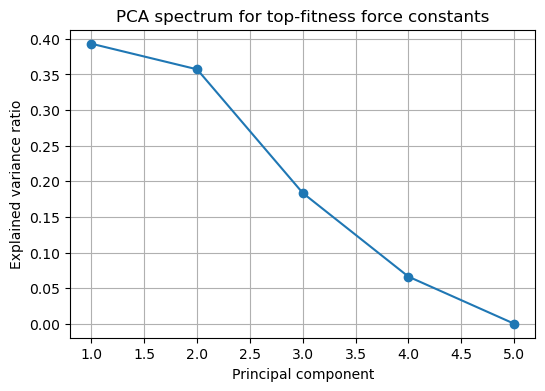

In [11]:
plt.figure(figsize=(6,4))
plt.plot(
    np.arange(1, len(fc_cols)+1),
    pca.explained_variance_ratio_,
    marker="o",
)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA spectrum for top-fitness force constants")
plt.grid(True)
plt.show()

In [12]:
#loadings

In [130]:
import itertools
import math

import matplotlib.pyplot as plt

In [131]:
# Number of principal components available
n_pcs = X_pca.shape[1]

# All pairwise PC combinations
pc_pairs = list(itertools.combinations(range(n_pcs), 2))

print(pc_pairs)

[(0, 1)]


ValueError: 'c' argument has 3900 elements, which is inconsistent with 'x' and 'y' with size 42.

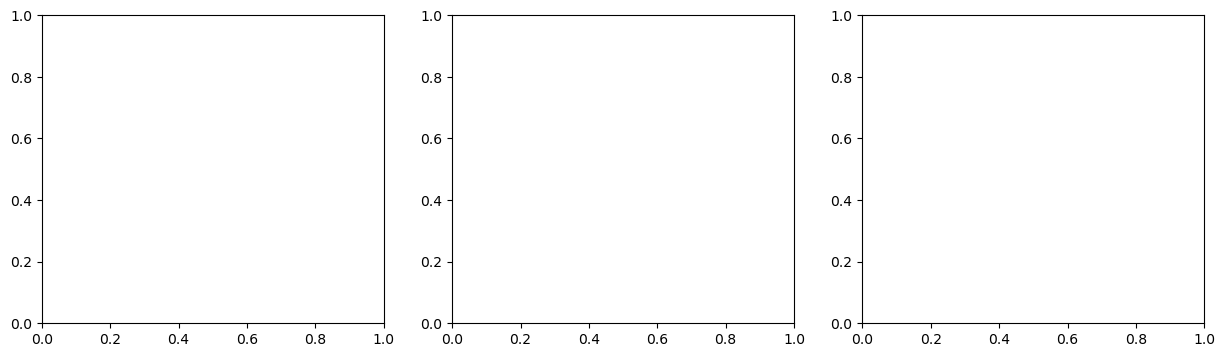

In [132]:
# Plot every PC plane

ncols = 3
nrows = math.ceil(len(pc_pairs) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5*ncols, 4*nrows),
)

axes = axes.ravel()

for ax, (i, j) in zip(axes, pc_pairs):

    sc = ax.scatter(
        X_pca[:, i],
        X_pca[:, j],
        c=top_df["fitness_norm"],
        s=8,
        alpha=0.7,
    )

    ax.set_xlabel(f"PC{i+1}")
    ax.set_ylabel(f"PC{j+1}")

    ax.set_title(
        f"PC{i+1} vs PC{j+1}"
    )

# Turn off unused axes
for ax in axes[len(pc_pairs):]:
    ax.axis("off")

# Shared colorbar
cbar = fig.colorbar(
    sc,
    ax=axes.tolist(),
    shrink=0.8,
)

cbar.set_label("fitness_norm")

plt.tight_layout()

plt.show()

In [13]:
loadings = pd.DataFrame(
    pca.components_,
    columns=fc_cols,
    index=[f"PC{i+1}" for i in range(len(fc_cols))]
)

loadings

,alpha0,alpha1,beta1,alpha2,beta2
PC1,0.698758,-0.689441,-0.136259,-0.119465,-0.059753
PC2,-0.083800,0.024344,-0.270691,-0.666555,0.689069
PC3,0.085135,-0.075934,0.952242,-0.231527,0.163148
PC4,-0.251929,-0.423421,0.037341,0.625385,0.603942
PC5,0.658786,0.582260,0.001315,0.311000,0.360903


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# PC5 near-null constraint from the PCA loadings
top_df["PC5_constraint"] = (
    0.658786 * top_df["alpha0"]
    + 0.582260 * top_df["alpha1"]
    + 0.001315 * top_df["beta1"]
    + 0.311000 * top_df["alpha2"]
    + 0.360903 * top_df["beta2"]
)

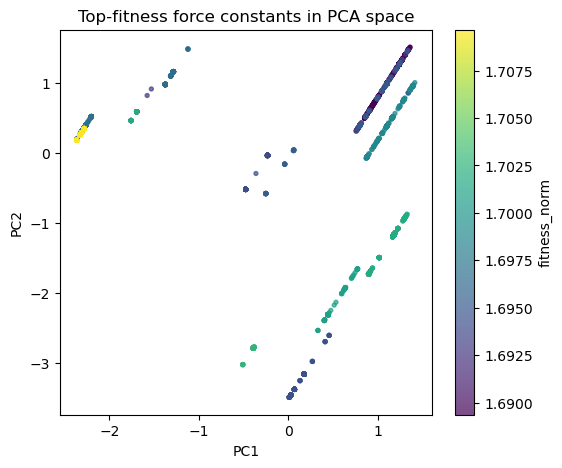

In [15]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=top_df["fitness_norm"],
    s=8,
    alpha=0.7,
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Top-fitness force constants in PCA space")
plt.colorbar(sc, label="fitness_norm")
plt.show()

In [16]:
top_df["PC5_constraint"].describe()

count    3900.000000
mean        4.093024
std         1.644988
min         1.337899
25%         2.718595
50%         5.202013
75%         5.283805
max         5.286660
Name: PC5_constraint, dtype: float64

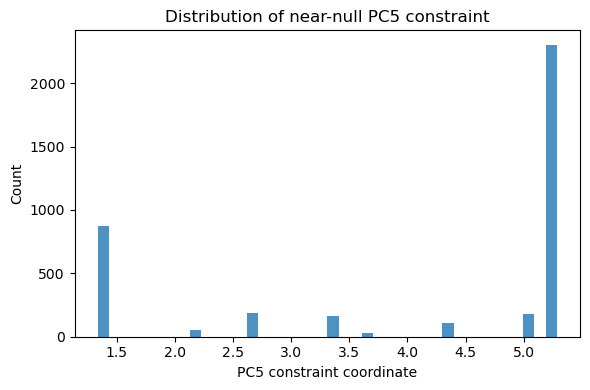

In [17]:
plt.figure(figsize=(6,4))

plt.hist(
    top_df["PC5_constraint"],
    bins=40,
    alpha=0.8,
)

plt.xlabel("PC5 constraint coordinate")
plt.ylabel("Count")
plt.title("Distribution of near-null PC5 constraint")

plt.tight_layout()
plt.show()

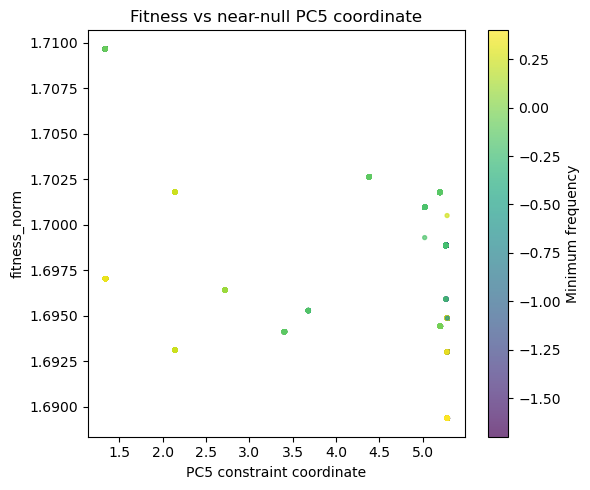

In [18]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    top_df["PC5_constraint"],
    top_df["fitness_norm"],
    c=top_df["min_frequency"],
    s=8,
    alpha=0.7,
)

plt.xlabel("PC5 constraint coordinate")
plt.ylabel("fitness_norm")
plt.title("Fitness vs near-null PC5 coordinate")

plt.colorbar(sc, label="Minimum frequency")

plt.tight_layout()
plt.show()

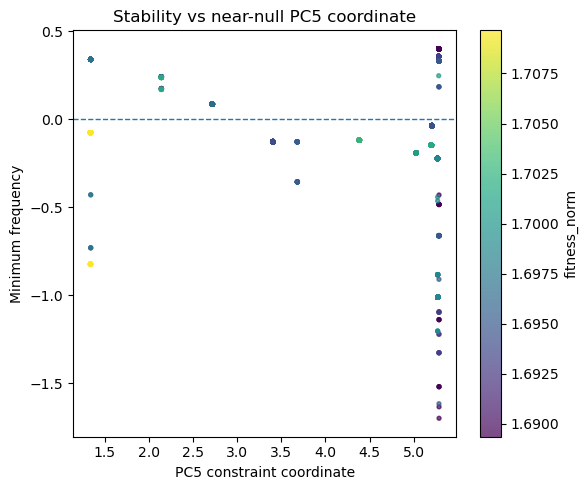

In [19]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    top_df["PC5_constraint"],
    top_df["min_frequency"],
    c=top_df["fitness_norm"],
    s=8,
    alpha=0.7,
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("PC5 constraint coordinate")
plt.ylabel("Minimum frequency")
plt.title("Stability vs near-null PC5 coordinate")

plt.colorbar(sc, label="fitness_norm")

plt.tight_layout()
plt.show()

In [20]:
# Compare with the acoustic-sum-rule-like quantity
top_df["S_like"] = (
    top_df["alpha0"]
    + 8.0 * top_df["alpha1"]
    + 2.0 * top_df["alpha2"]
    + 4.0 * top_df["beta2"]
)

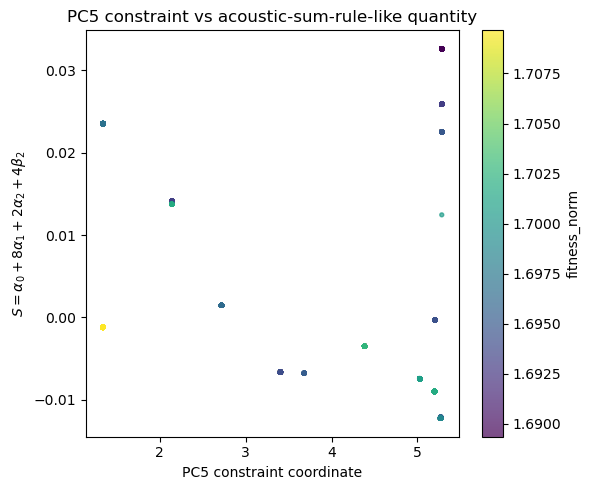

In [21]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    top_df["PC5_constraint"],
    top_df["S_like"],
    c=top_df["fitness_norm"],
    s=8,
    alpha=0.7,
)

plt.xlabel("PC5 constraint coordinate")
plt.ylabel(r"$S = \alpha_0 + 8\alpha_1 + 2\alpha_2 + 4\beta_2$")
plt.title("PC5 constraint vs acoustic-sum-rule-like quantity")

plt.colorbar(sc, label="fitness_norm")

plt.tight_layout()
plt.show()

/Users/jamunoz/miniconda3/envs/moga/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


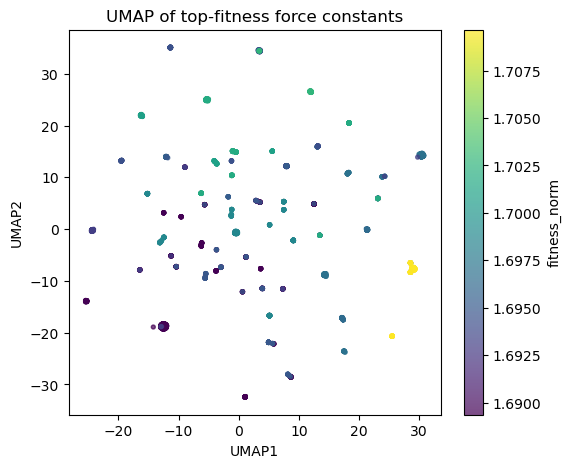

In [22]:
import umap

reducer = umap.UMAP(
    n_neighbors=25,
    min_dist=0.05,
    metric="euclidean",
    random_state=42,
)

X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=top_df["fitness_norm"],
    s=8,
    alpha=0.7,
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of top-fitness force constants")
plt.colorbar(sc, label="fitness_norm")
plt.show()

In [23]:
print("Correlation PC5_constraint vs S_like:")
print(top_df[["PC5_constraint", "S_like"]].corr())

Correlation PC5_constraint vs S_like:
                PC5_constraint    S_like
PC5_constraint        1.000000 -0.029713
S_like               -0.029713  1.000000


In [24]:
# Optional: inspect the best-constrained high-fitness rows
top_df.sort_values("PC5_constraint")[
    [
        "simulation",
        "generation",
        "solution_index",
        "rank",
        "mass",
        "a_val",
        "alpha0",
        "alpha1",
        "beta1",
        "alpha2",
        "beta2",
        "fitness_norm",
        "min_frequency",
        "num_imaginary",
        "PC5_constraint",
        "S_like",
    ]
].head()

,simulation,generation,solution_index,rank,mass,a_val,alpha0,alpha1,beta1,alpha2,beta2,fitness_norm,min_frequency,num_imaginary,PC5_constraint,S_like
8768,simulation000467,254,7,3,50.0,3.0,2.540301,-0.089888,0.004452,-0.910425,-0.000391,1.709656,-0.077853,31,1.337899,-0.00122
8736,simulation000467,248,2,1,50.0,3.0,2.540301,-0.089888,0.004452,-0.910425,-0.000391,1.709656,-0.077853,31,1.337899,-0.00122
8733,simulation000467,247,7,3,50.0,3.0,2.540301,-0.089888,0.004452,-0.910425,-0.000391,1.709656,-0.077853,31,1.337899,-0.00122
8767,simulation000467,254,5,2,50.0,3.0,2.540301,-0.089888,0.004452,-0.910425,-0.000391,1.709656,-0.077853,31,1.337899,-0.00122
8731,simulation000467,247,2,1,50.0,3.0,2.540301,-0.089888,0.004452,-0.910425,-0.000391,1.709656,-0.077853,31,1.337899,-0.00122


In [25]:
top_df.sort_values("PC5_constraint")[
    [
        "simulation",
        "generation",
        "solution_index",
        "rank",
        "mass",
        "a_val",
        "alpha0",
        "alpha1",
        "beta1",
        "alpha2",
        "beta2",
        "fitness_norm",
        "min_frequency",
        "num_imaginary",
        "PC5_constraint",
        "S_like",
    ]
].tail()

,simulation,generation,solution_index,rank,mass,a_val,alpha0,alpha1,beta1,alpha2,beta2,fitness_norm,min_frequency,num_imaginary,PC5_constraint,S_like
1034,simulation000462,207,49,4,50.0,2.0,9.491026,-0.763596,1.247043,-1.69091,0.008048,1.689362,-1.520281,82,5.286614,0.032628
1058,simulation000462,212,36,3,50.0,2.0,9.491026,-0.763596,1.247043,-1.69091,0.008048,1.689362,-1.520281,82,5.286614,0.032628
1067,simulation000462,214,21,2,50.0,2.0,9.491026,-0.763596,1.247043,-1.69091,0.008048,1.689362,-1.520281,82,5.286614,0.032628
517,simulation000462,104,11,2,50.0,2.0,9.491026,-0.763596,1.268771,-1.69091,0.008048,1.689362,-1.634699,85,5.286643,0.032628
571,simulation000462,115,4,1,50.0,2.0,9.491026,-0.763596,1.281353,-1.69091,0.008048,1.689362,-1.699516,88,5.286660,0.032628


In [26]:
scores = []

for k in range(2, 9):
    labels = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto",
    ).fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    scores.append((k, score))

scores_df = pd.DataFrame(scores, columns=["k", "silhouette"])
scores_df

,k,silhouette
0,2,0.286987
1,3,0.550000
2,4,0.552839
3,5,0.615069
4,6,0.624027
5,7,0.626294
6,8,0.671518


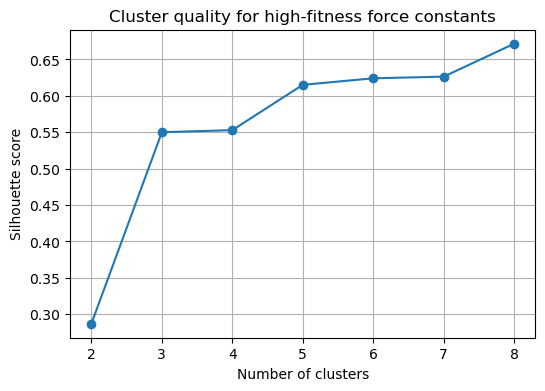

In [27]:
plt.figure(figsize=(6,4))
plt.plot(scores_df["k"], scores_df["silhouette"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Cluster quality for high-fitness force constants")
plt.grid(True)
plt.show()

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [29]:
fc_cols = ["alpha0", "alpha1", "beta1", "alpha2", "beta2"]

# Use top_df if already defined; otherwise define top 5%
q = 0.95
threshold = df["fitness_norm"].quantile(q)
top_df = df[df["fitness_norm"] >= threshold].copy()

X = top_df[fc_cols].to_numpy(dtype=np.float32)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [30]:
for k in [5, 6]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto",
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    top_df[f"cluster_k{k}"] = labels

    print(f"k={k}, silhouette={score:.4f}")

k=5, silhouette=0.6151
k=6, silhouette=0.6240


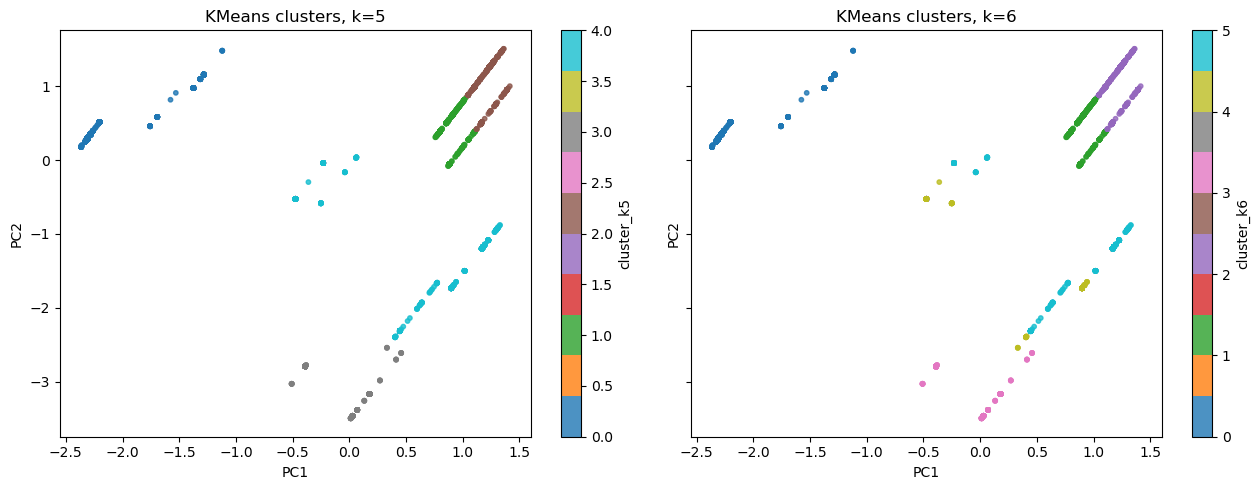

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for ax, k in zip(axes, [5, 6]):

    sc = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=top_df[f"cluster_k{k}"],
        s=10,
        alpha=0.8,
        cmap="tab10",
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"KMeans clusters, k={k}")

    plt.colorbar(sc, ax=ax, label=f"cluster_k{k}")

plt.tight_layout()
plt.show()

In [32]:
for k in [5, 6]:
    print(f"\nCluster summary for k={k}")
    display(
        top_df
        .groupby(f"cluster_k{k}")[
            fc_cols + ["fitness_norm", "min_frequency", "num_imaginary"]
        ]
        .agg(["count", "mean", "std", "min", "max"])
    )


Cluster summary for k=5


alpha0                                         alpha1            \
            count      mean       std       min       max  count      mean   
cluster_k5                                                                   
0            1114  3.057406  1.002336  2.540301  5.159819   1114 -0.110301   
1             527  9.420256  0.069112  9.352872  9.491026    527 -0.808545   
2            1177  9.469666  0.049964  9.352872  9.491026   1177 -0.777162   
3             361  8.594983  0.649145  7.629670  9.033562    361 -0.444936   
4             721  8.079969  1.255769  5.939623  8.913353    721 -0.810835   

                                          ... min_frequency            \
                 std       min       max  ...         count      mean   
cluster_k5                                ...                           
0           0.038563 -0.183470 -0.089888  ...          1114  0.159042   
1           0.043896 -0.851331 -0.763596  ...           527 -0.363772   
2           0.031734 -0.851331 -0.763596  ...          1177  0.289335   
3           0.074290 -0.707916 -0.338299  ...           361 -0.064062   
4           0.145560 -0.957111 -0.628959  ...           721 -0.157893   

                                         num_imaginary                        \
                 std       min       max         count       mean        std   
cluster_k5                                                                     
0           0.227855 -0.823992  0.339066          1114   9.542190  19.173547   
1           0.641876 -1.699516  0.399247           527  56.506641  51.753726   
2           0.220728 -0.223562  0.399247          1177   6.273577  14.721563   
3           0.039875 -0.193133 -0.037215           361  15.313019   8.522785   
4           0.035367 -0.356644 -0.127773           721  40.477115  11.651769   

                     
           min  max  
cluster_k5           
0            0  115  
1            0  125  
2            0   48  
3            9   60  
4           31   97  

[5 rows x 40 columns]


Cluster summary for k=6


alpha0                                         alpha1            \
            count      mean       std       min       max  count      mean   
cluster_k6                                                                   
0            1114  3.057406  1.002336  2.540301  5.159819   1114 -0.110301   
1             527  9.420256  0.069112  9.352872  9.491026    527 -0.808545   
2            1177  9.469666  0.049964  9.352872  9.491026   1177 -0.777162   
3             358  8.594356  0.651830  7.629670  9.033562    358 -0.442732   
4             165  7.522552  1.435533  5.939623  8.913353    165 -0.783969   
5             559  8.247667  1.144959  5.939623  8.913353    559 -0.818213   

                                          ... min_frequency            \
                 std       min       max  ...         count      mean   
cluster_k6                                ...                           
0           0.038563 -0.183470 -0.089888  ...          1114  0.159042   
1           0.043896 -0.851331 -0.763596  ...           527 -0.363772   
2           0.031734 -0.851331 -0.763596  ...          1177  0.289335   
3           0.070564 -0.490278 -0.338299  ...           358 -0.062980   
4           0.154745 -0.957111 -0.628959  ...           165 -0.161530   
5           0.141739 -0.957111 -0.628959  ...           559 -0.157009   

                                         num_imaginary                        \
                 std       min       max         count       mean        std   
cluster_k6                                                                     
0           0.227855 -0.823992  0.339066          1114   9.542190  19.173547   
1           0.641876 -1.699516  0.399247           527  56.506641  51.753726   
2           0.220728 -0.223562  0.399247          1177   6.273577  14.721563   
3           0.038239 -0.119572 -0.037215           358  14.938547   7.505115   
4           0.059765 -0.356644 -0.127773           165  55.109091  16.868942   
5           0.023795 -0.191723 -0.127773           559  36.262970   3.534861   

                     
           min  max  
cluster_k6           
0            0  115  
1            0  125  
2            0   48  
3            9   26  
4           35   97  
5           31   62  

[6 rows x 40 columns]

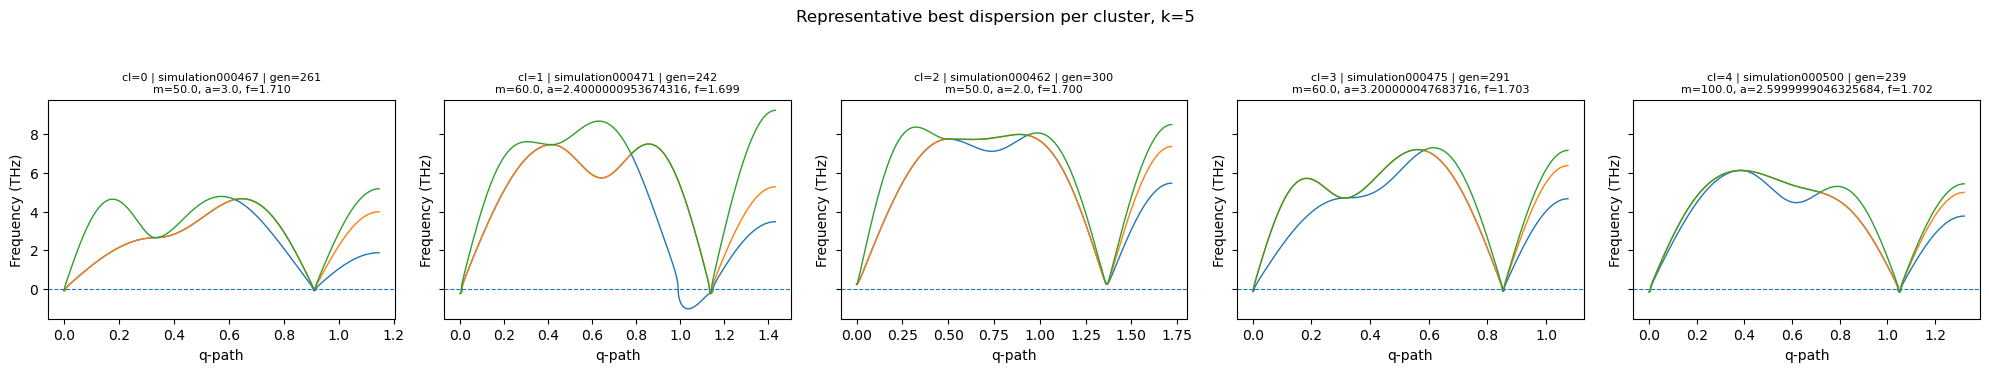

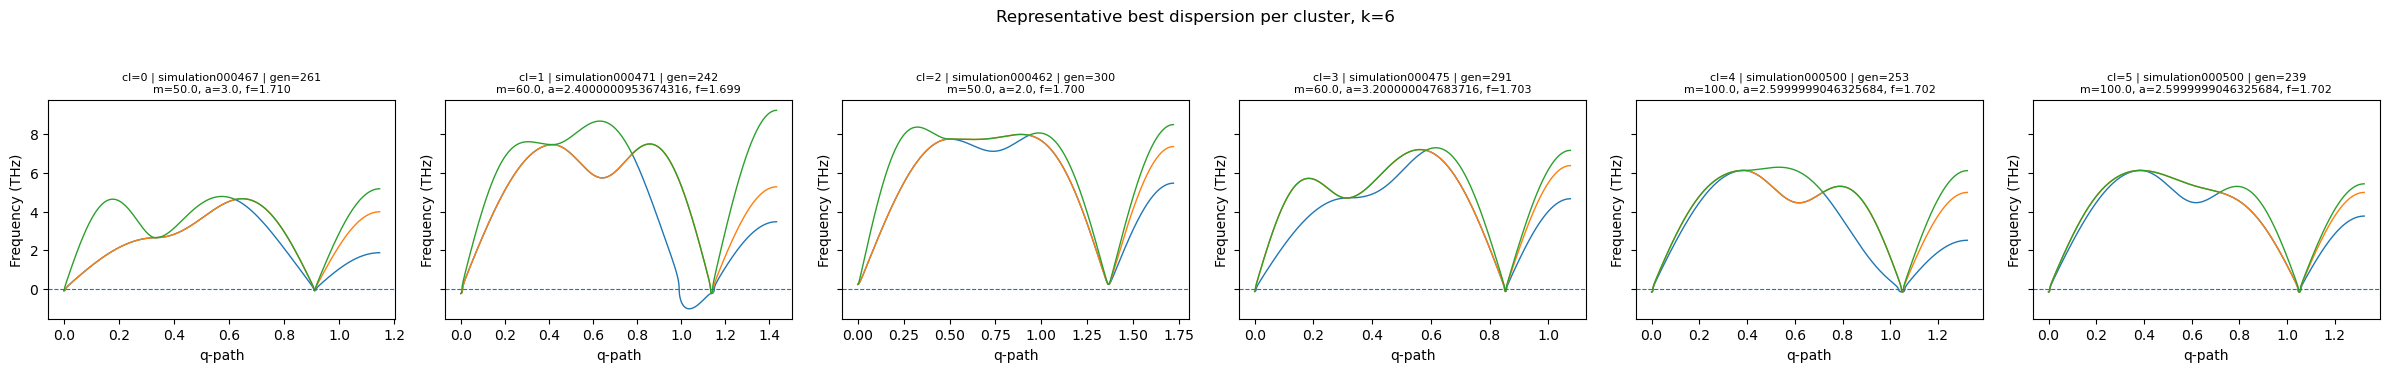

In [33]:
# Plot representative best dispersion from each cluster

def plot_dispersion_from_row(row, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    distances = row["distances"]
    freqs = row["frequencies"]

    for b in range(freqs.shape[1]):
        ax.plot(distances, freqs[:, b], linewidth=1)

    ax.axhline(0, linestyle="--", linewidth=0.8)

    ax.set_title(
        f"cl={row['cluster']} | {row['simulation']} | gen={row['generation']}\n"
        f"m={row['mass']}, a={row['a_val']}, f={row['fitness_norm']:.3f}",
        fontsize=8,
    )

    ax.set_xlabel("q-path")
    ax.set_ylabel("Frequency (THz)")


for k in [5, 6]:

    cluster_col = f"cluster_k{k}"

    reps = (
        top_df
        .sort_values("fitness_norm", ascending=False)
        .groupby(cluster_col, as_index=False)
        .first()
    )

    n = len(reps)

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(4*n, 3.5),
        sharey=True,
    )

    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, reps.iterrows()):
        row = row.copy()
        row["cluster"] = row[cluster_col]
        plot_dispersion_from_row(row, ax=ax)

    fig.suptitle(f"Representative best dispersion per cluster, k={k}", y=1.05)

    plt.tight_layout()
    plt.show()

In [34]:
k_best = 4

kmeans = KMeans(
    n_clusters=k_best,
    random_state=42,
    n_init="auto",
)

top_df["cluster"] = kmeans.fit_predict(X_scaled)

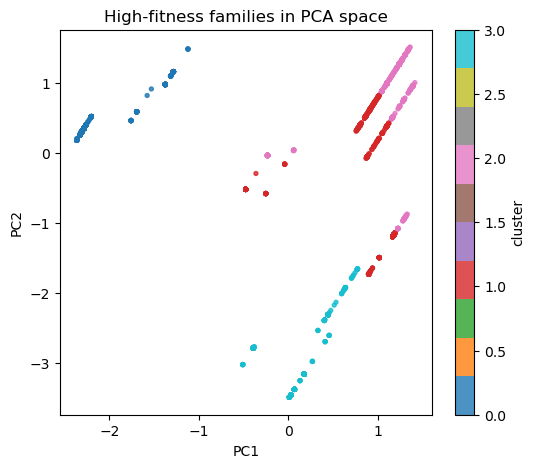

In [35]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=top_df["cluster"],
    s=8,
    alpha=0.8,
    cmap="tab10",
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("High-fitness families in PCA space")
plt.colorbar(sc, label="cluster")
plt.show()

In [36]:
cluster_summary = (
    top_df
    .groupby("cluster")[fc_cols + ["fitness_norm", "min_frequency", "num_imaginary"]]
    .agg(["mean", "std", "min", "max"])
)

cluster_summary

alpha0                                  alpha1                      \
             mean       std       min       max      mean       std       min   
cluster                                                                         
0        3.057406  1.002336  2.540301  5.159819 -0.110301  0.038563 -0.183470   
1        8.943474  0.955291  5.939623  9.491026 -0.842012  0.099106 -0.957111   
2        9.165356  0.953512  5.939623  9.491026 -0.772620  0.061988 -0.957111   
3        8.619619  0.532669  7.629670  9.033562 -0.531454  0.137823 -0.707916   

                      beta1            ... fitness_norm            \
              max      mean       std  ...          min       max   
cluster                                ...                          
0       -0.089888  0.016336  0.266985  ...     1.693109  1.709656   
1       -0.628959  0.492525  0.582655  ...     1.689362  1.701768   
2       -0.628959 -0.628823  0.328074  ...     1.689362  1.701768   
3       -0.338299  0.209211  0.446746  ...     1.694412  1.702624   

        min_frequency                               num_imaginary             \
                 mean       std       min       max          mean        std   
cluster                                                                        
0            0.159042  0.227855 -0.823992  0.339066      9.542190  19.173547   
1           -0.275312  0.498935 -1.699516  0.399247     51.046053  40.956753   
2            0.239534  0.247970 -0.223562  0.399247     10.310629  17.717849   
3           -0.106060  0.068338 -0.193133 -0.037215     21.460967  11.346718   

                  
        min  max  
cluster           
0         0  115  
1         0  125  
2         0   62  
3         9   60  

[4 rows x 32 columns]

In [37]:
def plot_dispersion_from_row(row, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    distances = row["distances"]
    freqs = row["frequencies"]

    for b in range(freqs.shape[1]):
        ax.plot(distances, freqs[:, b], linewidth=1)

    ax.axhline(0, linestyle="--", linewidth=0.8)

    ax.set_title(
        f"cluster {row['cluster']} | {row['simulation']} | gen {row['generation']}\n"
        f"m={row['mass']}, a={row['a_val']}, f={row['fitness_norm']:.3f}",
        fontsize=9,
    )

    ax.set_xlabel("q-path")
    ax.set_ylabel("Frequency (THz)")

    return ax

In [38]:
representatives = []

for cluster, g in top_df.groupby("cluster"):
    row = g.sort_values("fitness_norm", ascending=False).iloc[0]
    representatives.append(row)

rep_df = pd.DataFrame(representatives)

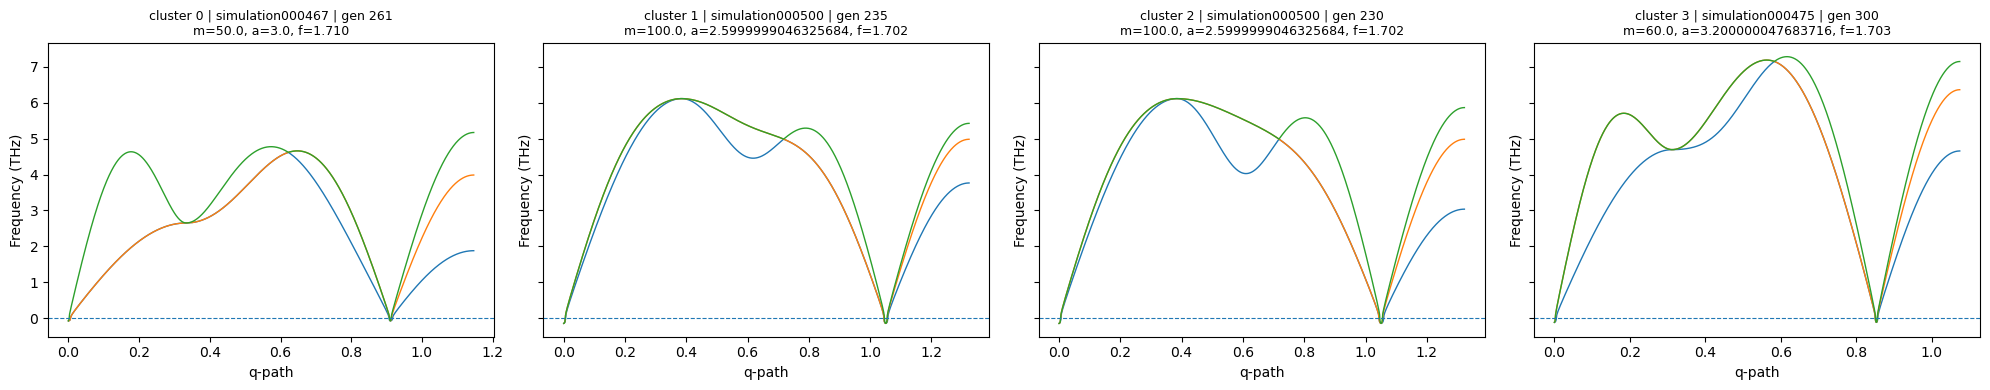

In [39]:
n = len(rep_df)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=True)

if n == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, rep_df.iterrows()):
    plot_dispersion_from_row(row, ax=ax)

plt.tight_layout()
plt.show()

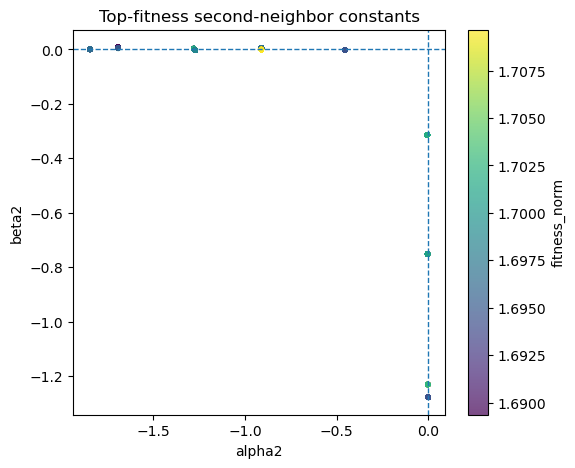

In [40]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    top_df["alpha2"],
    top_df["beta2"],
    c=top_df["fitness_norm"],
    s=8,
    alpha=0.7,
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("alpha2")
plt.ylabel("beta2")
plt.title("Top-fitness second-neighbor constants")
plt.colorbar(sc, label="fitness_norm")
plt.show()

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
# Use top_df if already defined; otherwise define top 5%
q = 0.95
threshold = df["fitness_norm"].quantile(q)

top_df = df[df["fitness_norm"] >= threshold].copy()

print("fitness threshold:", threshold)
print("top_df rows:", len(top_df))

fitness threshold: 1.689361572265625
top_df rows: 3900


In [43]:
# Define sparse 2NN branches
eps = 0.05

top_df["branch_2nn"] = "mixed"

top_df.loc[
    top_df["beta2"].abs() < eps,
    "branch_2nn"
] = "beta2 ≈ 0"

top_df.loc[
    top_df["alpha2"].abs() < eps,
    "branch_2nn"
] = "alpha2 ≈ 0"

top_df.loc[
    (top_df["alpha2"].abs() < eps) &
    (top_df["beta2"].abs() < eps),
    "branch_2nn"
] = "alpha2 ≈ beta2 ≈ 0"

top_df["branch_2nn"].value_counts()

branch_2nn
beta2 ≈ 0     3010
alpha2 ≈ 0     890
Name: count, dtype: int64

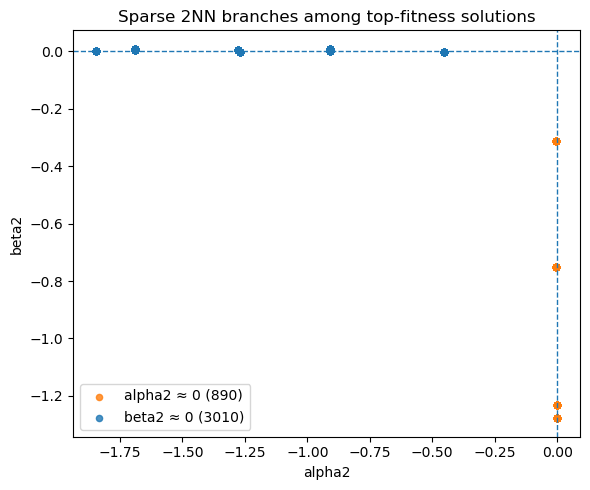

In [44]:
plt.figure(figsize=(6,5))

branch_colors = {
    "beta2 ≈ 0": "tab:blue",
    "alpha2 ≈ 0": "tab:orange",
    "alpha2 ≈ beta2 ≈ 0": "tab:green",
    "mixed": "tab:gray",
}

for branch, g in top_df.groupby("branch_2nn"):
    plt.scatter(
        g["alpha2"],
        g["beta2"],
        s=20,
        alpha=0.8,
        label=f"{branch} ({len(g)})",
        color=branch_colors.get(branch, None),
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("alpha2")
plt.ylabel("beta2")
plt.title("Sparse 2NN branches among top-fitness solutions")
plt.legend()

plt.tight_layout()
plt.show()

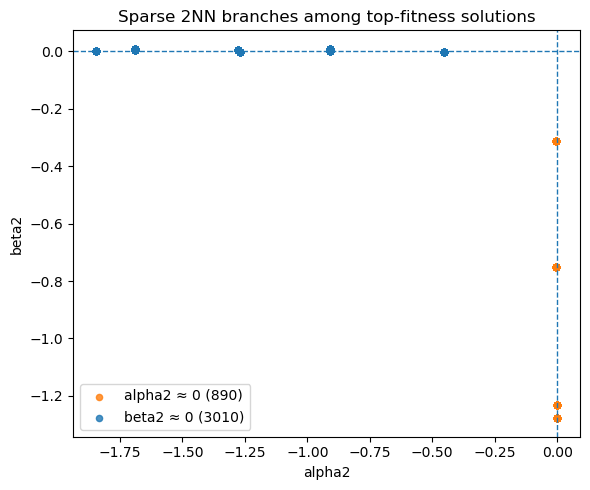

In [45]:
plt.figure(figsize=(6,5))

branch_colors = {
    "beta2 ≈ 0": "tab:blue",
    "alpha2 ≈ 0": "tab:orange",
    "alpha2 ≈ beta2 ≈ 0": "tab:green",
    "mixed": "tab:gray",
}

for branch, g in top_df.groupby("branch_2nn"):
    plt.scatter(
        g["alpha2"],
        g["beta2"],
        s=20,
        alpha=0.8,
        label=f"{branch} ({len(g)})",
        color=branch_colors.get(branch, None),
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("alpha2")
plt.ylabel("beta2")
plt.title("Sparse 2NN branches among top-fitness solutions")
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
# Branch-level statistics
summary_cols = [
    "fitness_norm",
    "min_frequency",
    "num_imaginary",
    "alpha0",
    "alpha1",
    "beta1",
    "alpha2",
    "beta2",
    "mass",
    "a_val",
]

branch_summary = (
    top_df
    .groupby("branch_2nn")[summary_cols]
    .agg(["count", "mean", "std", "min", "max"])
)

branch_summary

fitness_norm                                         min_frequency  \
                  count      mean       std       min       max         count   
branch_2nn                                                                      
alpha2 ≈ 0          890  1.699675  0.003289  1.694412  1.702624           890   
beta2 ≈ 0          3010  1.695717  0.005847  1.689362  1.709656          3010   

                                                    ...  mass             \
                mean       std       min       max  ... count       mean   
branch_2nn                                          ...                    
alpha2 ≈ 0 -0.122803  0.057008 -0.193133 -0.037215  ...   890  73.797752   
beta2 ≈ 0   0.099116  0.408977 -1.699516  0.399247  ...  3010  54.873753   

                                   a_val                                
                  std   min    max count      mean       std  min  max  
branch_2nn                                                              
alpha2 ≈ 0  21.521528  50.0  100.0   890  2.635056  0.228524  2.4  3.2  
beta2 ≈ 0   12.353522  50.0  100.0  3010  2.488239  0.478506  2.0  3.2  

[2 rows x 50 columns]

/var/folders/q4/9jxwyrx94pq6gsv5757mtyf80000gr/T/ipykernel_88562/699308329.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=branches, showfliers=False)


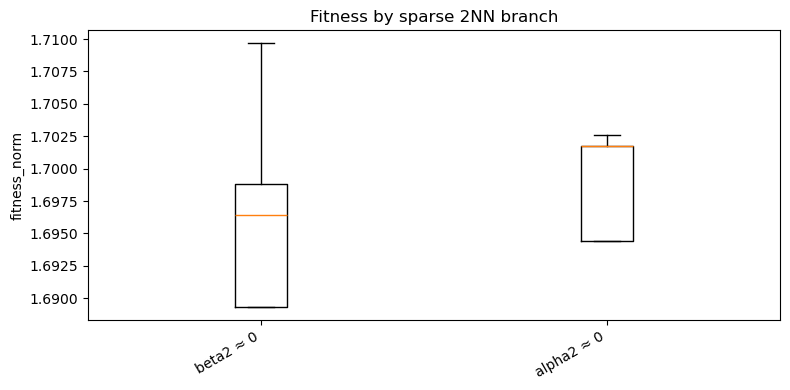

In [47]:
# Boxplot comparison of fitness by branch
plt.figure(figsize=(8,4))

branches = list(top_df["branch_2nn"].value_counts().index)

data = [
    top_df.loc[top_df["branch_2nn"] == b, "fitness_norm"].values
    for b in branches
]

plt.boxplot(data, labels=branches, showfliers=False)

plt.ylabel("fitness_norm")
plt.title("Fitness by sparse 2NN branch")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

/var/folders/q4/9jxwyrx94pq6gsv5757mtyf80000gr/T/ipykernel_88562/2370465108.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=branches, showfliers=False)


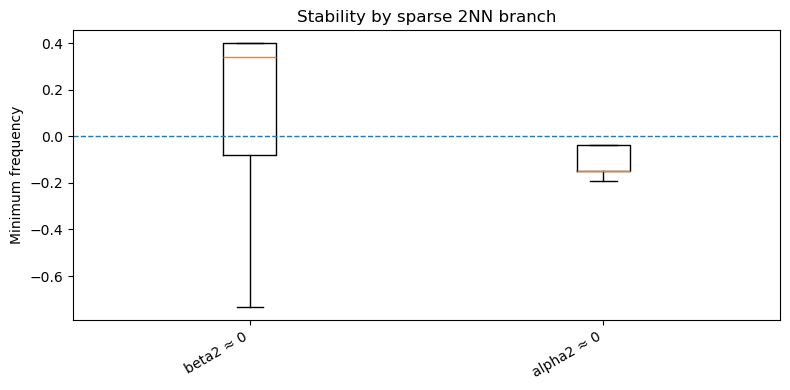

In [48]:
# Boxplot comparison of minimum frequency by branch
plt.figure(figsize=(8,4))

data = [
    top_df.loc[top_df["branch_2nn"] == b, "min_frequency"].values
    for b in branches
]

plt.boxplot(data, labels=branches, showfliers=False)

plt.axhline(0, linestyle="--", linewidth=1)

plt.ylabel("Minimum frequency")
plt.title("Stability by sparse 2NN branch")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [49]:
# Compare branch locations in PCA space if PC coordinates exist.
# If not, compute them.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

fc_cols = ["alpha0", "alpha1", "beta1", "alpha2", "beta2"]

X = top_df[fc_cols].to_numpy(dtype=np.float32)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

top_df["PC1"] = X_pca[:, 0]
top_df["PC2"] = X_pca[:, 1]

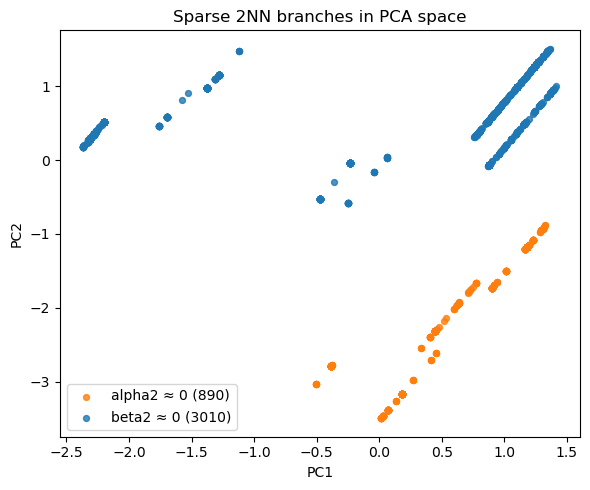

In [50]:
plt.figure(figsize=(6,5))

for branch, g in top_df.groupby("branch_2nn"):
    plt.scatter(
        g["PC1"],
        g["PC2"],
        s=18,
        alpha=0.8,
        label=f"{branch} ({len(g)})",
        color=branch_colors.get(branch, None),
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Sparse 2NN branches in PCA space")
plt.legend()

plt.tight_layout()
plt.show()

In [51]:
# If you already have KMeans cluster labels, compare branches with clusters.
# Replace cluster_k5 with your chosen cluster column if needed.

cluster_col = "cluster_k5"

if cluster_col in top_df.columns:
    branch_cluster_table = pd.crosstab(
        top_df["branch_2nn"],
        top_df[cluster_col],
        normalize="index",
    )

    display(branch_cluster_table)

    plt.figure(figsize=(7,4))
    plt.imshow(branch_cluster_table, aspect="auto")
    plt.colorbar(label="fraction within branch")

    plt.xticks(
        range(branch_cluster_table.shape[1]),
        branch_cluster_table.columns,
    )

    plt.yticks(
        range(branch_cluster_table.shape[0]),
        branch_cluster_table.index,
    )

    plt.xlabel("cluster")
    plt.ylabel("2NN branch")
    plt.title("Branch-cluster overlap")

    plt.tight_layout()
    plt.show()
else:
    print(f"{cluster_col} not found in top_df.")

cluster_k5 not found in top_df.


In [52]:
# Representative best dispersion from each sparse branch

def plot_dispersion_from_row(row, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    distances = row["distances"]
    freqs = row["frequencies"]

    for b in range(freqs.shape[1]):
        ax.plot(distances, freqs[:, b], linewidth=1)

    ax.axhline(0, linestyle="--", linewidth=0.8)

    ax.set_title(
        f"{row['branch_2nn']}\n"
        f"{row['simulation']} | gen={row['generation']}\n"
        f"m={row['mass']}, a={row['a_val']}, f={row['fitness_norm']:.3f}",
        fontsize=8,
    )

    ax.set_xlabel("q-path")
    ax.set_ylabel("Frequency (THz)")

    return ax

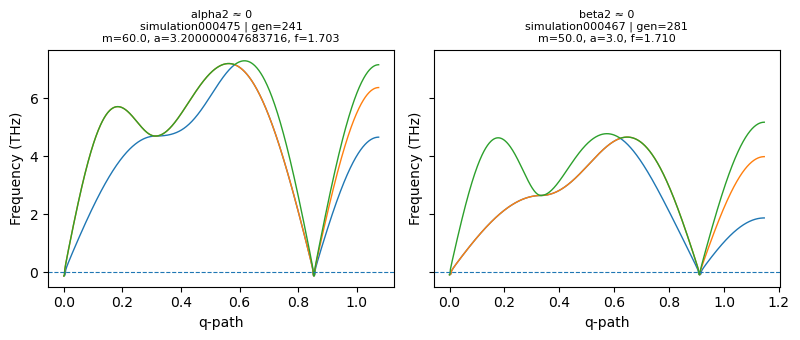

In [53]:
representatives = []

for branch, g in top_df.groupby("branch_2nn"):
    row = g.sort_values("fitness_norm", ascending=False).iloc[0]
    representatives.append(row)

rep_df = pd.DataFrame(representatives)

n = len(rep_df)

fig, axes = plt.subplots(
    1,
    n,
    figsize=(4*n, 3.5),
    sharey=True,
)

if n == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, rep_df.iterrows()):
    plot_dispersion_from_row(row, ax=ax)

plt.tight_layout()
plt.show()

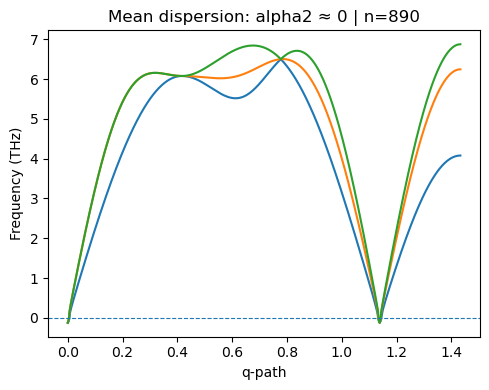

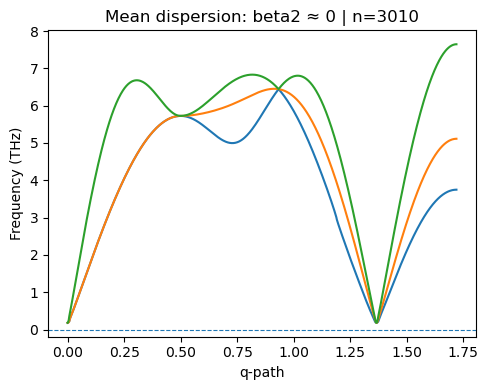

In [54]:
# Optional: compare mean dispersion per branch

def mean_dispersion(group):
    freqs = np.stack(group["frequencies"].values)
    return freqs.mean(axis=0), freqs.std(axis=0)

for branch, g in top_df.groupby("branch_2nn"):
    mean_freqs, std_freqs = mean_dispersion(g)

    distances = g.iloc[0]["distances"]

    plt.figure(figsize=(5,4))

    for b in range(mean_freqs.shape[1]):
        plt.plot(distances, mean_freqs[:, b], linewidth=1.5)

    plt.axhline(0, linestyle="--", linewidth=0.8)

    plt.xlabel("q-path")
    plt.ylabel("Frequency (THz)")
    plt.title(f"Mean dispersion: {branch} | n={len(g)}")

    plt.tight_layout()
    plt.show()

In [55]:
near_zero = top_df[
    (top_df["alpha2"].abs() < 0.1) &
    (top_df["beta2"].abs() < 0.1)
]

print("Near alpha2=beta2=0:", len(near_zero))
print("Fraction:", len(near_zero) / len(top_df))
near_zero["fitness_norm"].describe()

Near alpha2=beta2=0: 0
Fraction: 0.0


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: fitness_norm, dtype: float64

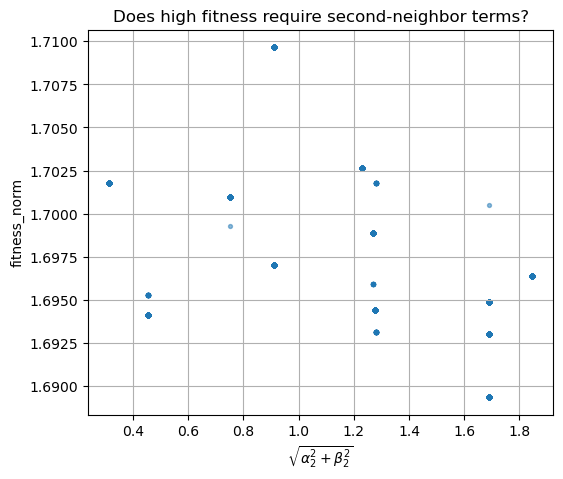

In [56]:
top_df["second_neighbor_norm"] = np.sqrt(
    top_df["alpha2"]**2 + top_df["beta2"]**2
)

plt.figure(figsize=(6,5))

plt.scatter(
    top_df["second_neighbor_norm"],
    top_df["fitness_norm"],
    s=8,
    alpha=0.5,
)

plt.xlabel(r"$\sqrt{\alpha_2^2+\beta_2^2}$")
plt.ylabel("fitness_norm")
plt.title("Does high fitness require second-neighbor terms?")
plt.grid(True)
plt.show()

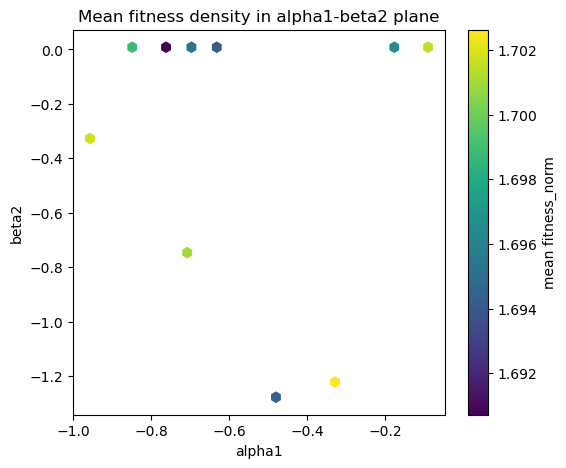

In [57]:
plt.figure(figsize=(6,5))

plt.hexbin(
    top_df["alpha1"],
    top_df["beta2"],
    C=top_df["fitness_norm"],
    gridsize=40,
    reduce_C_function=np.mean,
)

plt.xlabel("alpha1")
plt.ylabel("beta2")
plt.title("Mean fitness density in alpha1-beta2 plane")
plt.colorbar(label="mean fitness_norm")
plt.show()

## 1. Imports and paths

In [58]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes this notebook is run from the repo root.
repo_root = Path.cwd()

experiment_id = "experiment000009"
df_path = repo_root / "dataframes" / "dataframe000013.pkl"
summary_path = repo_root / "dataframes" / "dataframe000013.summary.json"

print("Repo root:", repo_root)
print("Dataframe:", df_path)
print("Summary:", summary_path)


Repo root: /Users/jamunoz/Documents/GitHub/MOGA-Phonons
Dataframe: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/dataframe000013.pkl
Summary: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/dataframe000013.summary.json


## 2. Load dataframe and summary

In [59]:
df = pd.read_pickle(df_path)

if summary_path.exists():
    with open(summary_path, "r") as f:
        summary = json.load(f)
else:
    summary = {}

print("Rows:", len(df))
print("Columns:", len(df.columns))
display(pd.DataFrame(summary.items(), columns=["field", "value"]))
display(df.head())


Rows: 105000
Columns: 34


,field,value
0,n_simulations_in_experiment,42
1,n_yaml_tasks,105000
2,n_missing_simulation_dirs,0
3,n_missing_phonon_dirs,0
4,n_simulations_with_no_yaml,0
5,missing_simulation_dirs,[]
6,missing_phonon_dirs,[]
7,simulations_with_no_yaml,[]
8,n_rows,105000
9,n_load_errors,0


,simulation,generation,solution_index,rank,source,timestamp,mass,a_val,system_size,alpha0,...,stable,gamma_frequencies,distances,qpoints,frequencies,frequency_vector,simulation_path,generation_dir,solution_dir,band_yaml_path
0,simulation000588,1,5,0,population,2026-05-22T19:33:42.238245,50.0,2.0,5,5.607430,...,True,"[0.8275024, 0.8275024, 0.8275024]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.8275024, 0.8275024, 0.8275024], [0.8291954...","[0.8275024, 0.8275024, 0.8275024, 0.8291954, 0...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...
1,simulation000588,1,92,1,population,2026-05-22T19:33:42.238245,50.0,2.0,5,6.189523,...,True,"[1.562392, 1.562392, 1.562392]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[1.562392, 1.562392, 1.562392], [1.563087, 1....","[1.562392, 1.562392, 1.562392, 1.563087, 1.563...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...
2,simulation000588,1,44,2,population,2026-05-22T19:33:42.238245,50.0,2.0,5,3.931578,...,False,"[-1.0034583, -1.0034583, -1.0034583]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.0034583, -1.0034583, -1.0034583], [-1.002...","[-1.0034583, -1.0034583, -1.0034583, -1.002285...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...
3,simulation000588,1,155,3,population,2026-05-22T19:33:42.238245,50.0,2.0,5,6.349680,...,True,"[1.0862614, 1.0862614, 1.0862614]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[1.0862614, 1.0862614, 1.0862614], [1.0880687...","[1.0862614, 1.0862614, 1.0862614, 1.0880687, 1...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...
4,simulation000588,1,125,4,population,2026-05-22T19:33:42.238245,50.0,2.0,5,8.587408,...,False,"[-1.2866693, -1.2866693, -1.2866693]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.2866693, -1.2866693, -1.2866693], [-1.284...","[-1.2866693, -1.2866693, -1.2866693, -1.284834...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...


## 3. Inspect dataframe schema

In [60]:
schema_rows = []
for c in df.columns:
    s = df[c]
    try:
        n_unique = s.nunique(dropna=True)
    except TypeError:
        n_unique = None
    schema_rows.append({
        "column": c,
        "dtype": str(s.dtype),
        "non_null": int(s.notna().sum()),
        "n_unique": n_unique,
    })

schema = pd.DataFrame(schema_rows)
display(schema)


,column,dtype,non_null,n_unique
0,simulation,object,105000,42.0
1,generation,int32,105000,500.0
2,solution_index,int32,105000,200.0
3,rank,int32,105000,5.0
4,source,object,105000,1.0
5,timestamp,object,105000,21000.0
6,mass,float32,105000,6.0
7,a_val,float32,105000,7.0
8,system_size,int32,105000,1.0
9,alpha0,float32,105000,653.0


## 4. Basic experiment coverage

This checks how many rows are available per simulation and per generation.


count    500.0
mean     210.0
std        0.0
min      210.0
25%      210.0
50%      210.0
75%      210.0
max      210.0
dtype: float64

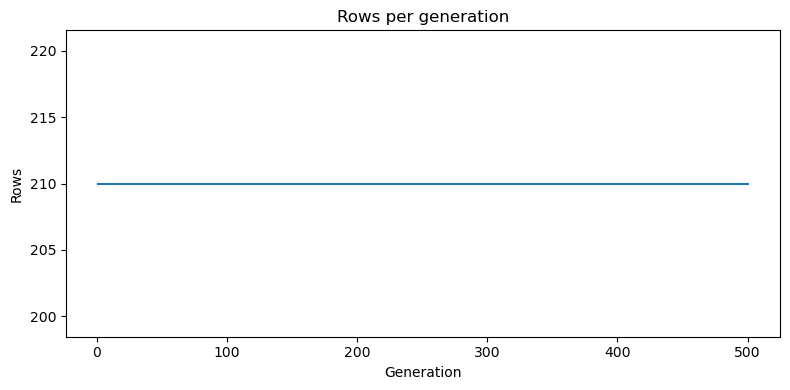

In [61]:
if "simulation_id" in df.columns:
    counts_by_sim = df.groupby("simulation_id").size().sort_index()
    display(counts_by_sim.describe())
    display(counts_by_sim.head())

    plt.figure(figsize=(10, 4))
    counts_by_sim.plot(kind="bar")
    plt.ylabel("Rows")
    plt.xlabel("Simulation")
    plt.title("Rows per simulation")
    plt.tight_layout()
    plt.show()

if "generation" in df.columns:
    counts_by_gen = df.groupby("generation").size().sort_index()
    display(counts_by_gen.describe())

    plt.figure(figsize=(8, 4))
    counts_by_gen.plot()
    plt.ylabel("Rows")
    plt.xlabel("Generation")
    plt.title("Rows per generation")
    plt.tight_layout()
    plt.show()


## 5. Stability overview

The builder adds `min_frequency`, `num_imaginary`, and `is_stable` when possible. These are useful first-pass metrics.


,min_frequency,max_frequency,num_imaginary
count,105000.000000,105000.000000,105000.000000
mean,-0.027717,6.639372,22.305476
std,0.253565,1.187252,36.164301
min,-3.720220,3.930611,0.000000
25%,-0.119855,5.776228,0.000000
50%,-0.020383,6.479097,9.000000
75%,0.092223,7.318994,30.000000
max,2.145909,10.694436,834.000000


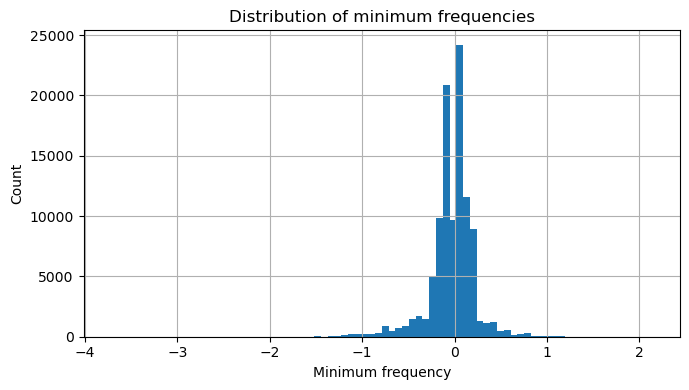

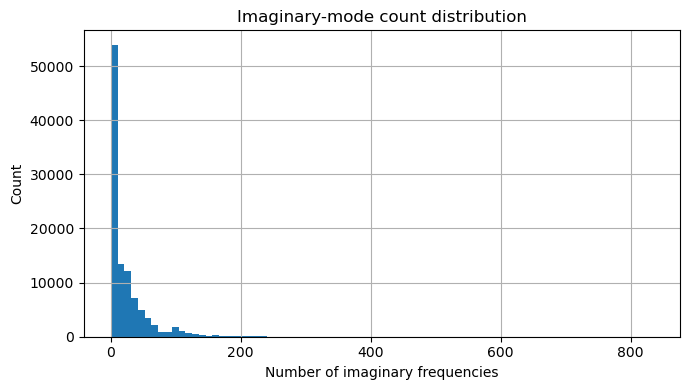

In [62]:
stability_cols = [c for c in ["min_frequency", "max_frequency", "num_imaginary", "is_stable"] if c in df.columns]
display(df[stability_cols].describe(include="all") if stability_cols else "No stability columns found.")

if "is_stable" in df.columns:
    stable_counts = df["is_stable"].value_counts(dropna=False)
    display(stable_counts)
    plt.figure(figsize=(5, 4))
    stable_counts.plot(kind="bar")
    plt.ylabel("Count")
    plt.title("Stable vs unstable candidates")
    plt.tight_layout()
    plt.show()

if "min_frequency" in df.columns:
    plt.figure(figsize=(7, 4))
    df["min_frequency"].dropna().hist(bins=80)
    plt.xlabel("Minimum frequency")
    plt.ylabel("Count")
    plt.title("Distribution of minimum frequencies")
    plt.tight_layout()
    plt.show()

if "num_imaginary" in df.columns:
    plt.figure(figsize=(7, 4))
    df["num_imaginary"].dropna().hist(bins=80)
    plt.xlabel("Number of imaginary frequencies")
    plt.ylabel("Count")
    plt.title("Imaginary-mode count distribution")
    plt.tight_layout()
    plt.show()


## 6. Fitness distributions

,fitness1,fitness2,fitness3,fitness_norm
count,105000.000000,105000.000000,105000.000000,105000.000000
mean,0.999979,0.987444,0.943538,1.694048
std,0.004009,0.032410,0.073852,0.044581
min,0.250000,0.221640,0.191488,1.224366
25%,1.000000,0.990652,0.937476,1.690658
50%,1.000000,0.996804,0.961068,1.707573
75%,1.000000,0.998878,0.975878,1.716419
max,1.000000,0.999997,1.000000,1.728936


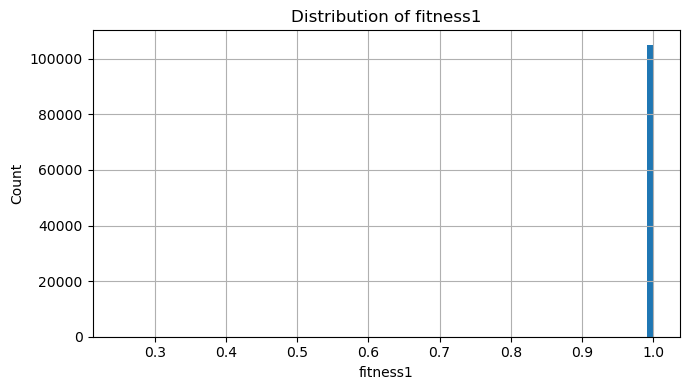

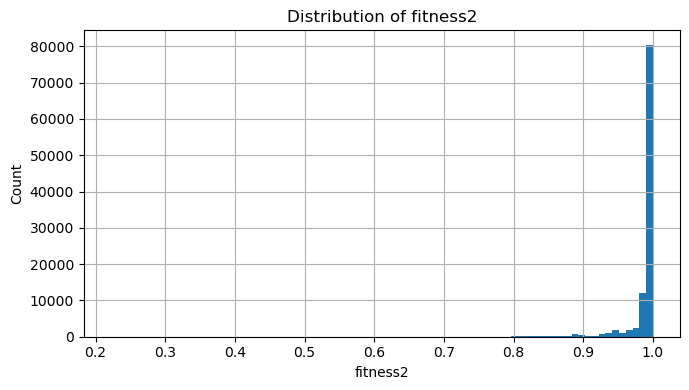

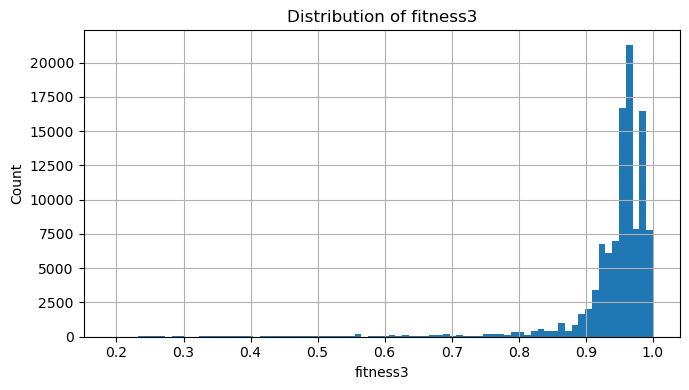

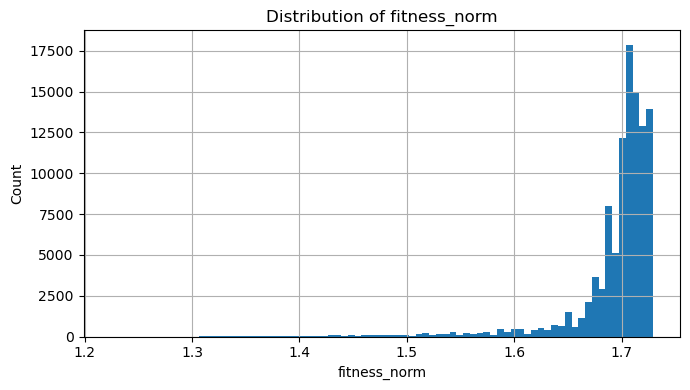

In [63]:
fitness_cols = [c for c in ["fitness1", "fitness2", "fitness3", "fitness_norm"] if c in df.columns]
display(df[fitness_cols].describe() if fitness_cols else "No fitness columns found.")

for col in fitness_cols:
    plt.figure(figsize=(7, 4))
    df[col].dropna().hist(bins=80)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


## 7. Fitness evolution by generation

This shows whether the top-k candidates improve across generations.


,mean,max,min,std,count
generation,,,,,
1,1.386821,1.585591,1.224366,0.066533,210
2,1.428341,1.644886,1.292360,0.061722,210
3,1.457672,1.687346,1.339179,0.061355,210
4,1.479012,1.687346,1.380618,0.062906,210
5,1.492184,1.687346,1.380618,0.064699,210


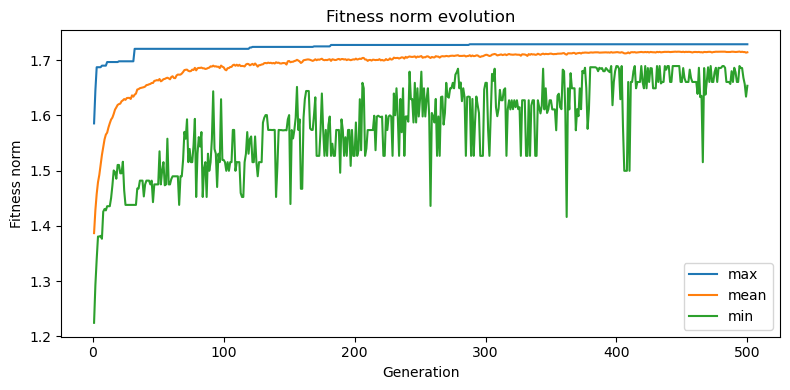

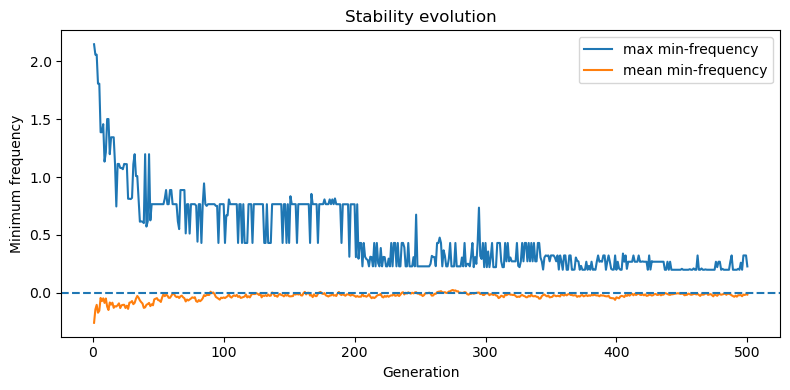

In [64]:
if "generation" in df.columns and "fitness_norm" in df.columns:
    gen_stats = df.groupby("generation")["fitness_norm"].agg(["mean", "max", "min", "std", "count"])
    display(gen_stats.head())

    plt.figure(figsize=(8, 4))
    gen_stats["max"].plot(label="max")
    gen_stats["mean"].plot(label="mean")
    gen_stats["min"].plot(label="min")
    plt.xlabel("Generation")
    plt.ylabel("Fitness norm")
    plt.title("Fitness norm evolution")
    plt.legend()
    plt.tight_layout()
    plt.show()

if "generation" in df.columns and "min_frequency" in df.columns:
    gen_minfreq = df.groupby("generation")["min_frequency"].agg(["mean", "max", "min"])
    plt.figure(figsize=(8, 4))
    gen_minfreq["max"].plot(label="max min-frequency")
    gen_minfreq["mean"].plot(label="mean min-frequency")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Generation")
    plt.ylabel("Minimum frequency")
    plt.title("Stability evolution")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 8. Parameter sweep maps

These plots summarize behavior over lattice parameter and mass, if `a_val` and `mass` or `atomic_masses` are available.


a_val,2.0,2.2,2.4,2.6,2.8,3.0,3.2
mass,,,,,,,
50.0,1.708806,1.701003,1.708816,1.707573,1.709460,1.712327,1.716595
60.0,1.722846,1.722815,1.689465,1.711113,1.725419,1.702433,1.724746
70.0,1.709569,1.711299,1.721261,1.721815,1.727140,1.716484,1.715251
80.0,1.727458,1.722845,1.717790,1.728759,1.718414,1.714747,1.708301
90.0,1.708725,1.728936,1.722689,1.720515,1.725250,1.711459,1.713182
100.0,1.718915,1.710186,1.724142,1.714420,1.717093,1.721740,1.716374


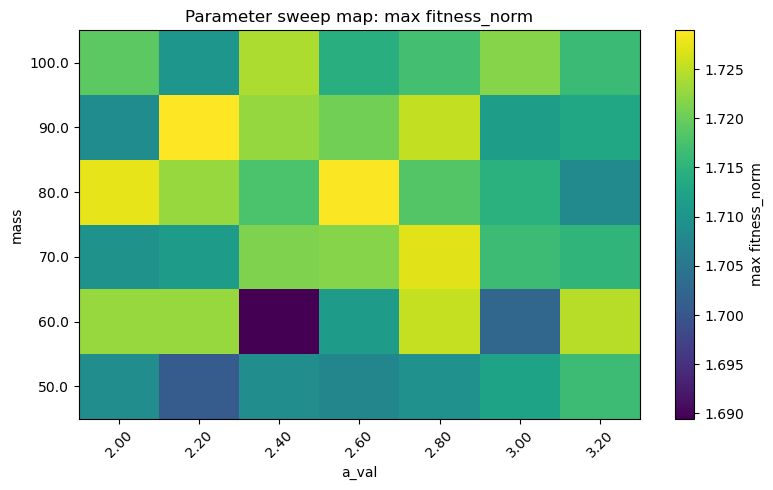

In [65]:
df_plot = df.copy()

if "mass" not in df_plot.columns and "atomic_masses" in df_plot.columns:
    def first_mass(x):
        if isinstance(x, (list, tuple, np.ndarray)):
            return float(x[0])
        return float(x)
    df_plot["mass"] = df_plot["atomic_masses"].map(first_mass)

metric = "fitness_norm" if "fitness_norm" in df_plot.columns else None
if metric and "a_val" in df_plot.columns and "mass" in df_plot.columns:
    pivot = df_plot.groupby(["mass", "a_val"])[metric].max().unstack("a_val")
    display(pivot)

    plt.figure(figsize=(8, 5))
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.colorbar(label=f"max {metric}")
    plt.xticks(range(len(pivot.columns)), [f"{x:.2f}" for x in pivot.columns], rotation=45)
    plt.yticks(range(len(pivot.index)), [f"{x:.1f}" for x in pivot.index])
    plt.xlabel("a_val")
    plt.ylabel("mass")
    plt.title(f"Parameter sweep map: max {metric}")
    plt.tight_layout()
    plt.show()

if "is_stable" in df_plot.columns and "a_val" in df_plot.columns and "mass" in df_plot.columns:
    stable_fraction = df_plot.groupby(["mass", "a_val"])["is_stable"].mean().unstack("a_val")
    display(stable_fraction)

    plt.figure(figsize=(8, 5))
    plt.imshow(stable_fraction.values, aspect="auto", origin="lower", vmin=0, vmax=1)
    plt.colorbar(label="stable fraction")
    plt.xticks(range(len(stable_fraction.columns)), [f"{x:.2f}" for x in stable_fraction.columns], rotation=45)
    plt.yticks(range(len(stable_fraction.index)), [f"{x:.1f}" for x in stable_fraction.index])
    plt.xlabel("a_val")
    plt.ylabel("mass")
    plt.title("Stable-candidate fraction across parameter sweep")
    plt.tight_layout()
    plt.show()


## 9. Force-constant relationships

Scatter plots of the reduced BvK parameters and their relation to fitness/stability.


,alpha0,alpha1,beta1,alpha2,beta2
count,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000
mean,7.254728,-0.414582,0.009385,-0.335472,-0.817057
std,1.593014,0.239001,0.475392,0.575500,0.669796
min,3.071748,-1.157311,-1.348521,-1.998058,-1.982378
25%,5.811642,-0.587865,-0.311258,-0.644083,-1.356110
50%,7.646986,-0.418439,-0.005803,-0.001817,-0.827943
75%,8.560993,-0.211469,0.339197,0.000248,-0.001577
max,9.994729,0.184210,1.311292,1.078593,0.374455


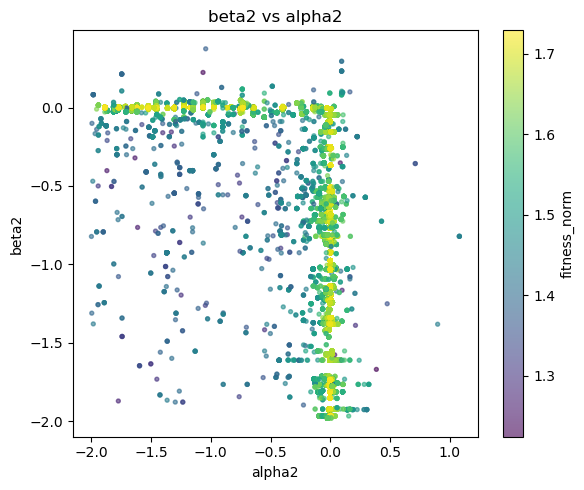

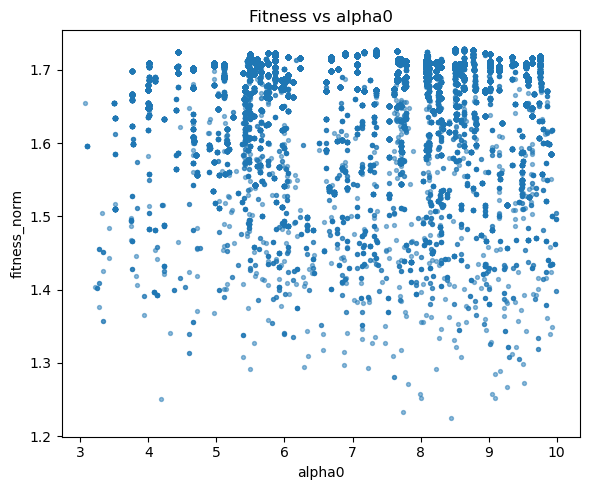

In [66]:
fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]
display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

if len(fc_cols) >= 2:
    color_col = "fitness_norm" if "fitness_norm" in df.columns else None
    xcol, ycol = "alpha2", "beta2"
    if xcol in df.columns and ycol in df.columns:
        plt.figure(figsize=(6, 5))
        if color_col:
            sc = plt.scatter(df[xcol], df[ycol], c=df[color_col], s=8, alpha=0.6)
            plt.colorbar(sc, label=color_col)
        else:
            plt.scatter(df[xcol], df[ycol], s=8, alpha=0.6)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(f"{ycol} vs {xcol}")
        plt.tight_layout()
        plt.show()

if "alpha0" in df.columns and "fitness_norm" in df.columns:
    plt.figure(figsize=(6, 5))
    plt.scatter(df["alpha0"], df["fitness_norm"], s=8, alpha=0.5)
    plt.xlabel("alpha0")
    plt.ylabel("fitness_norm")
    plt.title("Fitness vs alpha0")
    plt.tight_layout()
    plt.show()


,alpha0,alpha1,beta1,alpha2,beta2
count,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000
mean,7.254728,-0.414582,0.009385,-0.335472,-0.817057
std,1.593014,0.239001,0.475392,0.575500,0.669796
min,3.071748,-1.157311,-1.348521,-1.998058,-1.982378
25%,5.811642,-0.587865,-0.311258,-0.644083,-1.356110
50%,7.646986,-0.418439,-0.005803,-0.001817,-0.827943
75%,8.560993,-0.211469,0.339197,0.000248,-0.001577
max,9.994729,0.184210,1.311292,1.078593,0.374455


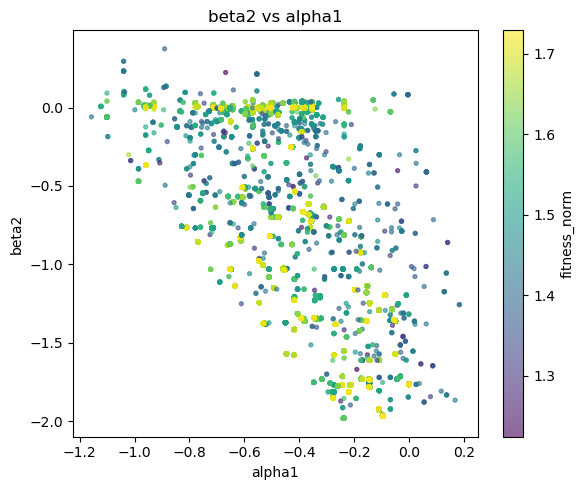

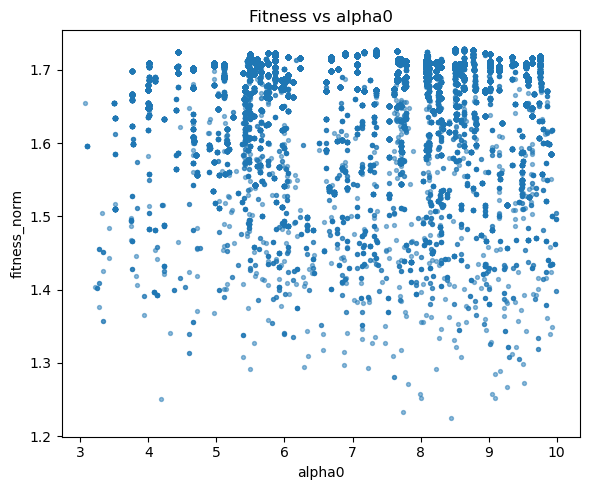

In [67]:
fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]
display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

if len(fc_cols) >= 2:
    color_col = "fitness_norm" if "fitness_norm" in df.columns else None
    xcol, ycol = "alpha1", "beta2"
    if xcol in df.columns and ycol in df.columns:
        plt.figure(figsize=(6, 5))
        if color_col:
            sc = plt.scatter(df[xcol], df[ycol], c=df[color_col], s=8, alpha=0.6)
            plt.colorbar(sc, label=color_col)
        else:
            plt.scatter(df[xcol], df[ycol], s=8, alpha=0.6)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(f"{ycol} vs {xcol}")
        plt.tight_layout()
        plt.show()

if "alpha0" in df.columns and "fitness_norm" in df.columns:
    plt.figure(figsize=(6, 5))
    plt.scatter(df["alpha0"], df["fitness_norm"], s=8, alpha=0.5)
    plt.xlabel("alpha0")
    plt.ylabel("fitness_norm")
    plt.title("Fitness vs alpha0")
    plt.tight_layout()
    plt.show()


,alpha0,alpha1,beta1,alpha2,beta2
count,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000
mean,7.254728,-0.414582,0.009385,-0.335472,-0.817057
std,1.593014,0.239001,0.475392,0.575500,0.669796
min,3.071748,-1.157311,-1.348521,-1.998058,-1.982378
25%,5.811642,-0.587865,-0.311258,-0.644083,-1.356110
50%,7.646986,-0.418439,-0.005803,-0.001817,-0.827943
75%,8.560993,-0.211469,0.339197,0.000248,-0.001577
max,9.994729,0.184210,1.311292,1.078593,0.374455


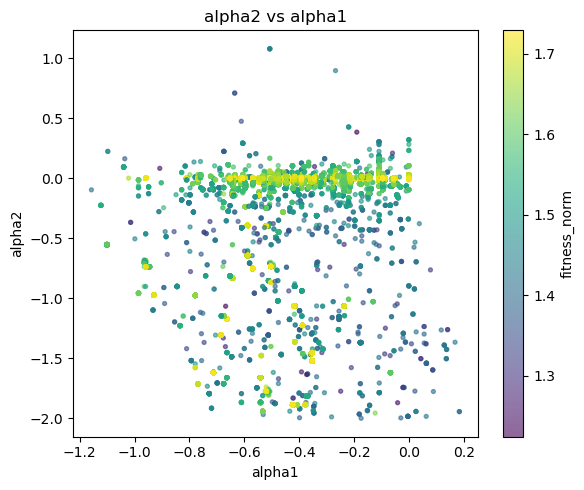

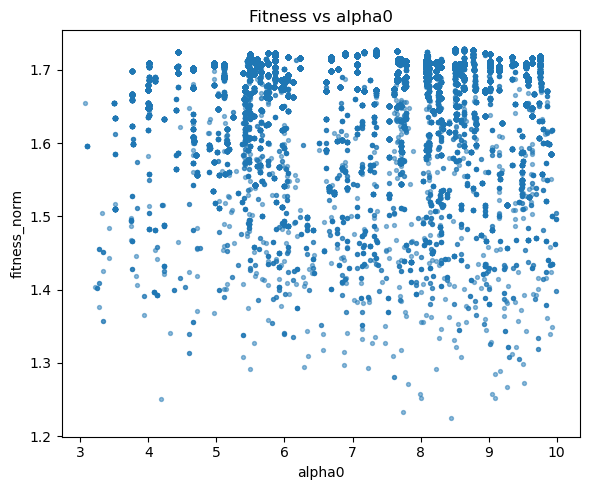

In [68]:
fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]
display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

if len(fc_cols) >= 2:
    color_col = "fitness_norm" if "fitness_norm" in df.columns else None
    xcol, ycol = "alpha1", "alpha2"
    if xcol in df.columns and ycol in df.columns:
        plt.figure(figsize=(6, 5))
        if color_col:
            sc = plt.scatter(df[xcol], df[ycol], c=df[color_col], s=8, alpha=0.6)
            plt.colorbar(sc, label=color_col)
        else:
            plt.scatter(df[xcol], df[ycol], s=8, alpha=0.6)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(f"{ycol} vs {xcol}")
        plt.tight_layout()
        plt.show()

if "alpha0" in df.columns and "fitness_norm" in df.columns:
    plt.figure(figsize=(6, 5))
    plt.scatter(df["alpha0"], df["fitness_norm"], s=8, alpha=0.5)
    plt.xlabel("alpha0")
    plt.ylabel("fitness_norm")
    plt.title("Fitness vs alpha0")
    plt.tight_layout()
    plt.show()

## 10. Top candidates

This table lists the highest-ranking candidates according to `fitness_norm`, with stable candidates prioritized if available.


In [69]:
preferred_cols = [
    "simulation_id", "generation", "solution_index", "rank",
    "a_val", "mass",
    "alpha0", "alpha1", "beta1", "alpha2", "beta2",
    "fitness1", "fitness2", "fitness3", "fitness_norm",
    "min_frequency", "num_imaginary", "is_stable",
    "yaml_path", "plot_path"
]
cols = [c for c in preferred_cols if c in df_plot.columns]

sort_cols = []
ascending = []
if "is_stable" in df_plot.columns:
    sort_cols.append("is_stable")
    ascending.append(False)
if "fitness_norm" in df_plot.columns:
    sort_cols.append("fitness_norm")
    ascending.append(False)
elif "min_frequency" in df_plot.columns:
    sort_cols.append("min_frequency")
    ascending.append(False)

top = df_plot.sort_values(sort_cols, ascending=ascending).head(25) if sort_cols else df_plot.head(25)
display(top[cols])


,generation,solution_index,rank,a_val,mass,alpha0,alpha1,beta1,alpha2,beta2,fitness1,fitness2,fitness3,fitness_norm,min_frequency,num_imaginary
74652,431,5,2,2.2,90.0,8.50909,-0.391584,0.139680,0.000121,-1.344109,1.0,0.999781,0.994816,1.728936,0.026056,0
74287,358,5,2,2.2,90.0,8.50909,-0.391584,0.139680,0.000121,-1.344109,1.0,0.999781,0.994816,1.728936,0.026056,0
74317,364,4,2,2.2,90.0,8.50909,-0.391584,-0.650352,0.000121,-1.344109,1.0,0.999781,0.994816,1.728936,0.026056,0
74316,364,3,1,2.2,90.0,8.50909,-0.391584,-0.650352,0.000121,-1.344109,1.0,0.999781,0.994816,1.728936,0.026056,0
74315,364,0,0,2.2,90.0,8.50909,-0.391584,0.139680,0.000121,-1.344109,1.0,0.999781,0.994816,1.728936,0.026056,0
74314,363,9,4,2.2,90.0,8.50909,-0.391584,-0.328092,0.000121,-1.344109,1.0,0.999781,0.994816,1.728936,0.026056,0
74313,363,6,3,2.2,90.0,8.50909,-0.391584,-0.650352,0.000121,-1.344109,1.0,0.999781,0.994816,1.728936,0.026056,0
74312,363,5,2,2.2,90.0,8.50909,-0.391584,0.901669,0.000121,-1.344109,1.0,0.999781,0.994816,1.728936,0.026056,0
74311,363,2,1,2.2,90.0,8.50909,-0.391584,-0.650352,0.000121,-1.344109,1.0,0.999781,0.994816,1.728936,0.026056,0
74310,363,0,0,2.2,90.0,8.50909,-0.391584,0.139680,0.000121,-1.344109,1.0,0.999781,0.994816,1.728936,0.026056,0


## 11. Save filtered subsets

Useful for making small curated datasets for plotting, manuscript figures, or Zenodo releases.


In [70]:
# Best row by fitness_norm for each (a_val, mass)
idx = df.groupby(["a_val", "mass"])["fitness_norm"].idxmax()

best_df = (
    df.loc[idx]
    .sort_values(["a_val", "mass"])
    .reset_index(drop=True)
)

best_df.head()

,simulation,generation,solution_index,rank,source,timestamp,mass,a_val,system_size,alpha0,...,stable,gamma_frequencies,distances,qpoints,frequencies,frequency_vector,simulation_path,generation_dir,solution_dir,band_yaml_path
0,simulation000588,305,102,0,population,2026-05-22T19:47:09.912003,50.0,2.0,5,8.589455,...,False,"[-0.018497573, -0.018497573, -0.018497573]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-0.018497573, -0.018497573, -0.018497573], [...","[-0.018497573, -0.018497573, -0.018497573, 0.0...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...
1,simulation000595,408,51,0,population,2026-05-22T22:31:42.694544,60.0,2.0,5,5.757267,...,False,"[-0.14370738, -0.14370738, -0.14370738]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-0.14370738, -0.14370738, -0.14370738], [-0....","[-0.14370738, -0.14370738, -0.14370738, -0.138...",simulations/simulation000595,simulations/simulation000595/phonon_generation...,simulations/simulation000595/phonon_generation...,simulations/simulation000595/phonon_generation...
2,simulation000602,404,198,0,population,2026-05-23T01:12:40.216651,70.0,2.0,5,9.631794,...,True,"[0.043821078, 0.043821078, 0.043821078]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.043821078, 0.043821078, 0.043821078], [0.0...","[0.043821078, 0.043821078, 0.043821078, 0.0640...",simulations/simulation000602,simulations/simulation000602/phonon_generation...,simulations/simulation000602/phonon_generation...,simulations/simulation000602/phonon_generation...
3,simulation000609,234,104,0,population,2026-05-23T03:47:56.977224,80.0,2.0,5,8.774649,...,True,"[0.08651447, 0.08651447, 0.08651447]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.08651447, 0.08651447, 0.08651447], [0.0901...","[0.08651447, 0.08651447, 0.08651447, 0.0901038...",simulations/simulation000609,simulations/simulation000609/phonon_generation...,simulations/simulation000609/phonon_generation...,simulations/simulation000609/phonon_generation...
4,simulation000616,372,23,0,population,2026-05-23T06:32:48.134221,90.0,2.0,5,5.115721,...,True,"[0.07479337, 0.07479337, 0.07479337]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.07479337, 0.07479337, 0.07479337], [0.0778...","[0.07479337, 0.07479337, 0.07479337, 0.0778772...",simulations/simulation000616,simulations/simulation000616/phonon_generation...,simulations/simulation000616/phonon_generation...,simulations/simulation000616/phonon_generation...


In [71]:
best_df[
    [
        "simulation",
        "generation",
        "a_val",
        "mass",
        "alpha0",
        "alpha1",
        "beta1",
        "alpha2",
        "beta2",
        "fitness_norm",
        "fitness1",
        "fitness2",
        "fitness3",
        "min_frequency",
        "num_imaginary",
    ]
]

,simulation,generation,a_val,mass,alpha0,alpha1,beta1,alpha2,beta2,fitness_norm,fitness1,fitness2,fitness3,min_frequency,num_imaginary
0,simulation000588,305,2.0,50.0,8.589455,-0.110056,0.321999,-0.000223,-1.927148,1.708806,1.0,0.999969,0.959208,-0.018498,9
1,simulation000595,408,2.0,60.0,5.757267,-0.387201,-0.036231,-0.002547,-0.664908,1.722846,1.0,0.994961,0.989066,-0.143707,31
2,simulation000602,404,2.0,70.0,9.631794,-0.634325,0.865743,0.000038,-1.139190,1.709569,1.0,0.999487,0.961068,0.043821,0
3,simulation000609,234,2.0,80.0,8.774649,-0.211477,-0.049239,0.001217,-1.770699,1.727458,1.0,0.997535,0.994503,0.086514,0
4,simulation000616,372,2.0,90.0,5.115721,-0.176397,0.191423,0.000727,-0.925978,1.708725,1.0,0.997915,0.961201,0.074793,0
5,simulation000623,362,2.0,100.0,9.758405,-0.530831,0.368759,0.001665,-1.377901,1.718915,1.0,0.996532,0.980609,0.092223,0
6,simulation000589,497,2.2,50.0,5.985896,-0.587865,0.218657,-0.641189,-0.000583,1.701003,1.0,0.998269,0.947031,-0.090619,21
7,simulation000596,150,2.2,60.0,8.938680,-0.712644,-1.130942,-1.618749,0.000162,1.722815,1.0,0.999320,0.984607,0.053398,0
8,simulation000603,460,2.2,70.0,8.261530,-0.417720,-0.086843,-0.000997,-1.229853,1.711299,1.0,0.998363,0.965305,-0.075439,18
9,simulation000610,499,2.2,80.0,6.889878,-0.606761,0.268923,-0.000352,-0.508929,1.722845,1.0,0.999371,0.984607,-0.043521,14


In [72]:
df_valid = df.dropna(subset=["fitness_norm"])

idx = df_valid.groupby(["a_val", "mass"])["fitness_norm"].idxmax()

best_df = (
    df_valid.loc[idx]
    .sort_values(["a_val", "mass"])
    .reset_index(drop=True)
)

In [73]:
from pathlib import Path

REPO_ROOT = Path.cwd()

best_df = best_df.copy()

best_df["dispersion_path"] = best_df["generation_dir"].apply(
    lambda p: REPO_ROOT / p / "dispersion.png"
)

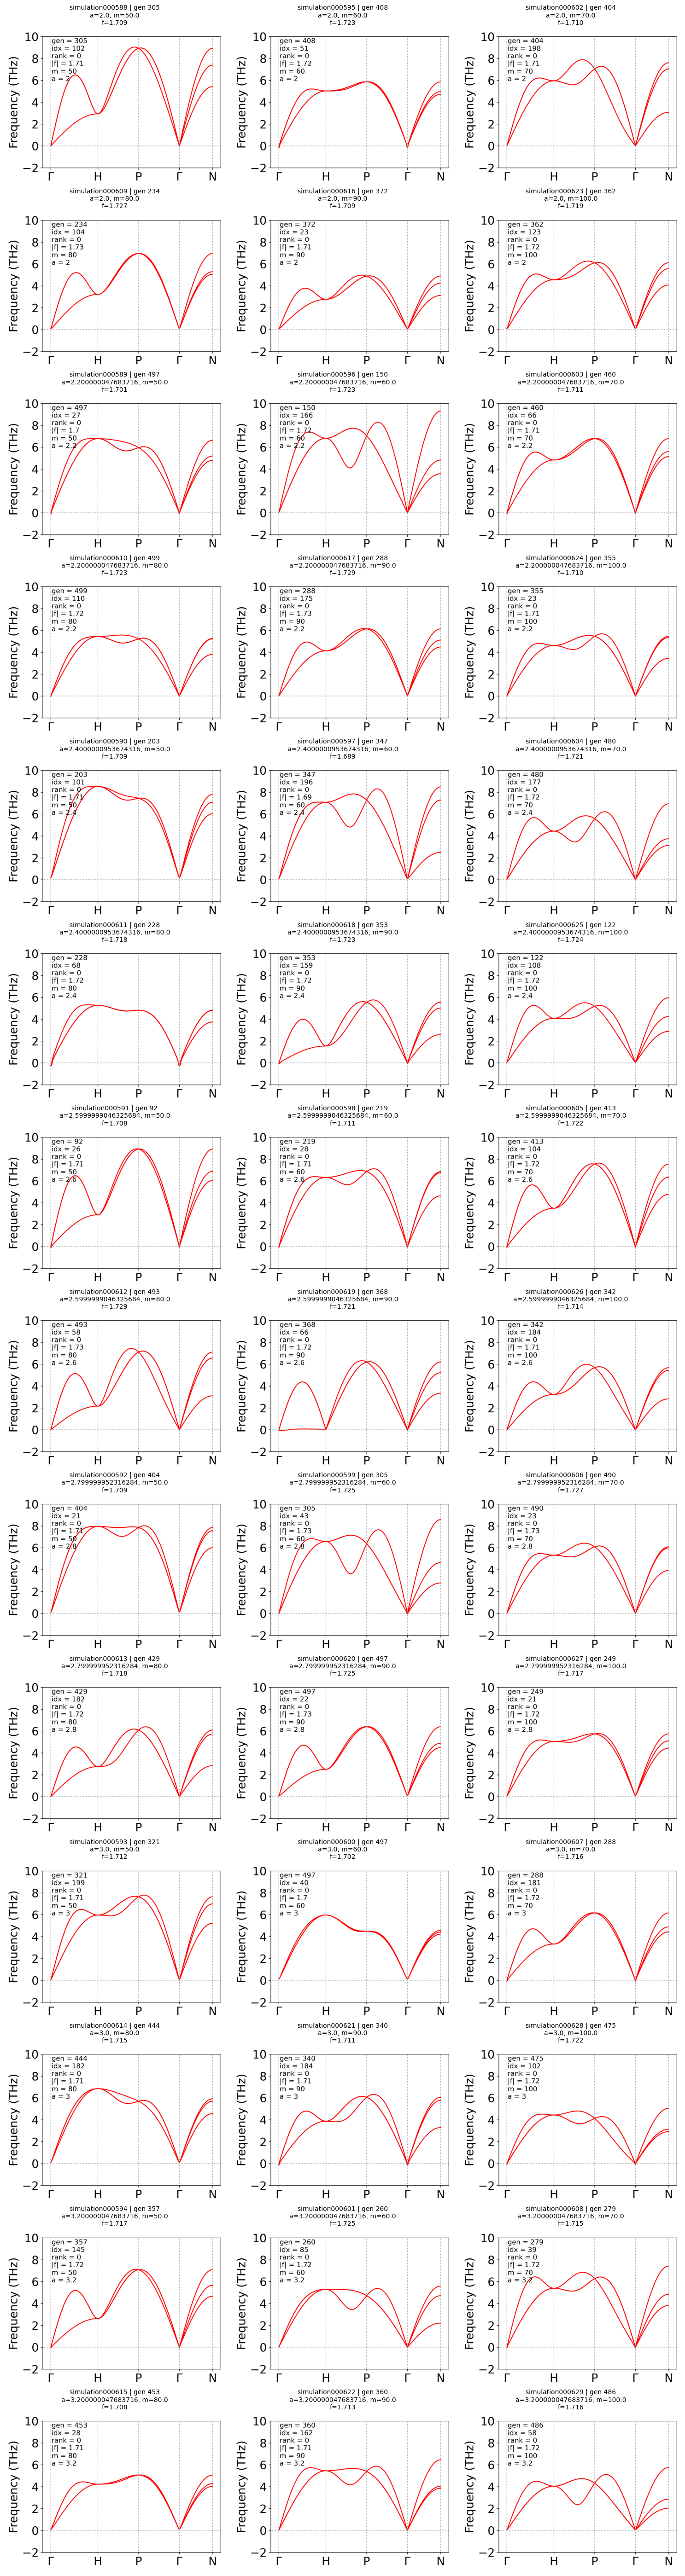

In [74]:
import math
from pathlib import Path

import matplotlib.pyplot as plt


def build_dispersion_path(row):
    """
    Build dispersion.png path from dataframe row.
    """

    generation_dir = f"generation_{int(row['generation']):06d}"

    # top-k/all selections
    if "solution_index" in row.index and "rank" in row.index:
        solution_dir = (
            f"solution_{int(row['solution_index']):06d}"
            f"_rank_{int(row['rank']):03d}"
        )

        return (
            Path(row["simulation_path"])
            / "phonon_generations"
            / generation_dir
            / solution_dir
            / "dispersion.png"
        )

    # fallback for selection="best"
    return (
        Path(row["simulation_path"])
        / "phonon_generations"
        / generation_dir
        / "dispersion.png"
    )


n = len(best_df)

ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5*ncols, 4*nrows),
)

axes = axes.ravel()

for ax, (_, row) in zip(axes, best_df.iterrows()):

    dispersion_path = build_dispersion_path(row)

    if not dispersion_path.is_file():
        ax.text(
            0.5,
            0.5,
            f"Missing:\n{dispersion_path.name}",
            ha="center",
            va="center",
        )
        ax.axis("off")
        continue

    img = plt.imread(dispersion_path)

    ax.imshow(img)
    ax.axis("off")

    ax.set_title(
        f"{row['simulation']} | gen {row['generation']}\n"
        f"a={row['a_val']}, m={row['mass']}\n"
        f"f={row['fitness_norm']:.3f}",
        fontsize=10,
    )

for ax in axes[len(best_df):]:
    ax.axis("off")

plt.tight_layout()

plt.show()

In [75]:
output_dir = repo_root / "dataframes" / "subsets"
output_dir.mkdir(parents=True, exist_ok=True)

if "is_stable" in df_plot.columns:
    stable_df = df_plot[df_plot["is_stable"] == True].copy()
    stable_path = output_dir / f"{experiment_id}_stable_candidates.pkl"
    stable_df.to_pickle(stable_path)
    print("Saved stable candidates:", stable_path, "rows =", len(stable_df))

if "fitness_norm" in df_plot.columns:
    top_path = output_dir / f"{experiment_id}_top100_by_fitness_norm.pkl"
    df_plot.sort_values("fitness_norm", ascending=False).head(100).to_pickle(top_path)
    print("Saved top 100:", top_path)


Saved top 100: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/subsets/experiment000009_top100_by_fitness_norm.pkl


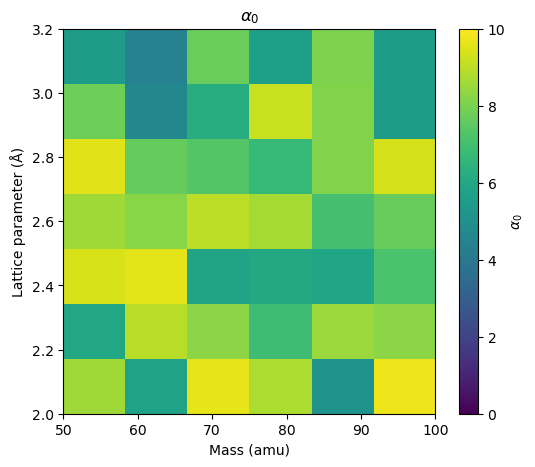

In [76]:
import matplotlib.pyplot as plt

pivot = best_df.pivot(
    index="a_val",
    columns="mass",
    values="alpha0",
)

plt.figure(figsize=(6,5))

plt.imshow(
    pivot,
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
    vmin=0.0,
    vmax=10.0,
)

plt.xlabel("Mass (amu)")
plt.ylabel("Lattice parameter (Å)")
plt.title(r"$\alpha_0$")

plt.colorbar(label=r"$\alpha_0$")

plt.show()

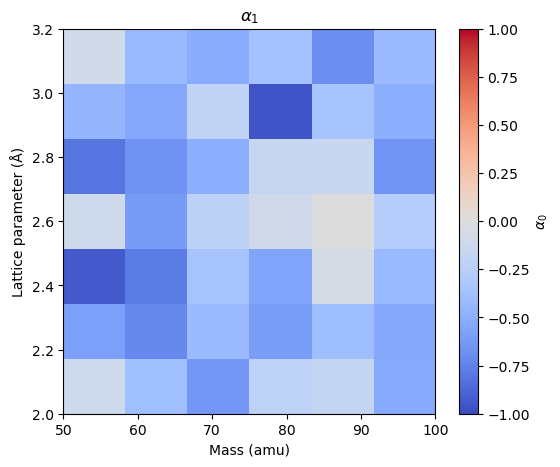

In [77]:
import matplotlib.pyplot as plt

pivot = best_df.pivot(
    index="a_val",
    columns="mass",
    values="alpha1",
)

plt.figure(figsize=(6,5))

plt.imshow(
    pivot,
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.xlabel("Mass (amu)")
plt.ylabel("Lattice parameter (Å)")
plt.title(r"$\alpha_1$")


plt.colorbar(label=r"$\alpha_0$")

plt.show()

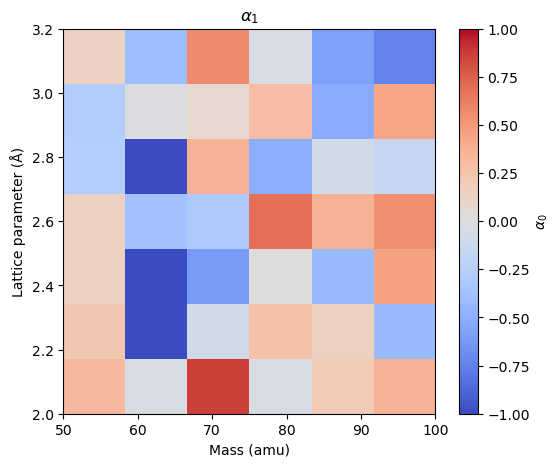

In [78]:
import matplotlib.pyplot as plt

pivot = best_df.pivot(
    index="a_val",
    columns="mass",
    values="beta1",
)

plt.figure(figsize=(6,5))

plt.imshow(
    pivot,
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.xlabel("Mass (amu)")
plt.ylabel("Lattice parameter (Å)")
plt.title(r"$\alpha_1$")


plt.colorbar(label=r"$\alpha_0$")

plt.show()

In [79]:
cols = [
    "mass",
    "a_val",
    "alpha0",
    "alpha1",
    "beta1",
    "alpha2",
    "beta2",
    "fitness_norm",
]

best_df[cols].corr()

,mass,a_val,alpha0,alpha1,beta1,alpha2,beta2,fitness_norm
mass,1.000000e+00,-1.118636e-15,-0.037622,0.162605,0.140860,-0.035183,-0.081007,0.341910
a_val,-1.118636e-15,1.000000e+00,-0.302682,-0.033858,-0.165312,-0.117476,0.247738,-0.004040
alpha0,-3.762240e-02,-3.026818e-01,1.000000,-0.338991,0.027784,0.099059,-0.366247,-0.097062
alpha1,1.626055e-01,-3.385802e-02,-0.338991,1.000000,0.195989,0.311268,-0.665774,0.306062
beta1,1.408603e-01,-1.653118e-01,0.027784,0.195989,1.000000,0.201291,-0.244866,0.102299
alpha2,-3.518302e-02,-1.174762e-01,0.099059,0.311268,0.201291,1.000000,-0.715089,-0.130072
beta2,-8.100741e-02,2.477379e-01,-0.366247,-0.665774,-0.244866,-0.715089,1.000000,-0.110001
fitness_norm,3.419103e-01,-4.040108e-03,-0.097062,0.306062,0.102299,-0.130072,-0.110001,1.000000


<Axes: >

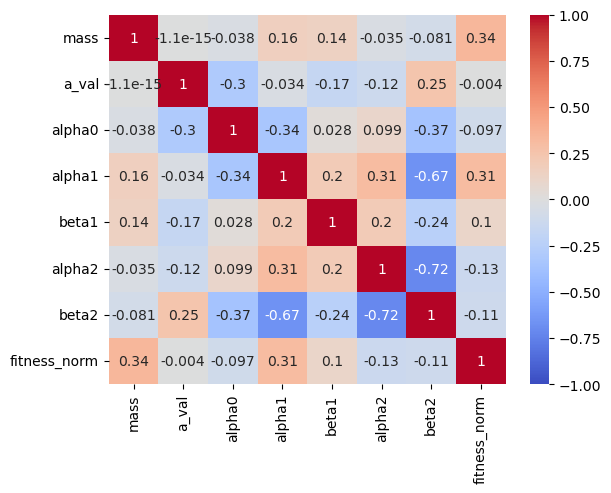

In [80]:
import seaborn as sns

sns.heatmap(best_df[cols].corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm")

In [81]:
X = best_df[
    ["alpha0","alpha1","beta1","alpha2","beta2"]
].values

In [82]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

fc_cols = [
    "alpha0",
    "alpha1",
    "beta1",
    "alpha2",
    "beta2",
]

X = best_df[fc_cols].values

In [83]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [84]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [85]:
print(pca.explained_variance_ratio_)

[0.45347944 0.2577022 ]


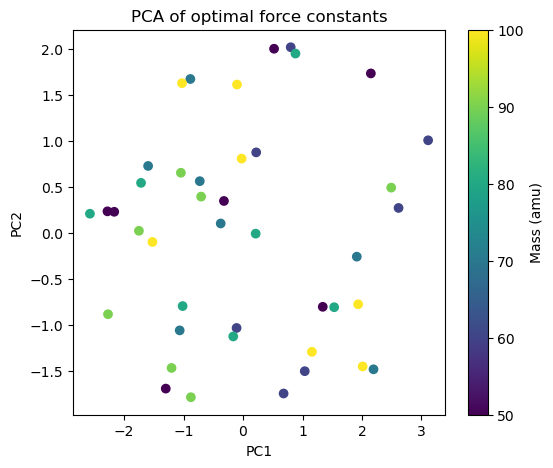

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=best_df["mass"],
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(sc, label="Mass (amu)")

plt.title("PCA of optimal force constants")

plt.show()

In [87]:
c=best_df["a_val"]

In [88]:
c=best_df["fitness_norm"]

In [89]:
loadings = pd.DataFrame(
    pca.components_,
    columns=fc_cols,
    index=["PC1", "PC2"],
)

loadings

,alpha0,alpha1,beta1,alpha2,beta2
PC1,-0.102507,-0.478836,-0.282584,-0.528024,0.633676
PC2,0.838077,-0.504867,-0.039663,0.120306,-0.163369


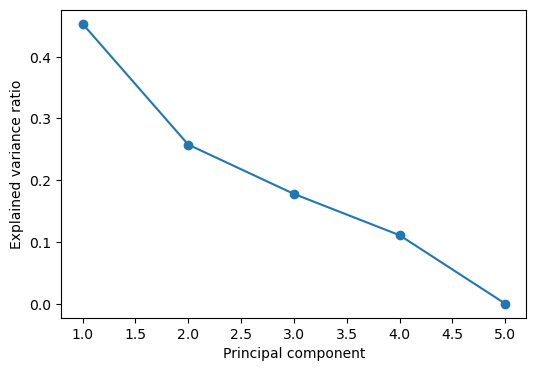

In [90]:
pca_full = PCA()

pca_full.fit(X_scaled)

plt.figure(figsize=(6,4))

plt.plot(
    range(1, len(fc_cols)+1),
    pca_full.explained_variance_ratio_,
    marker="o",
)

plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")

plt.show()

In [91]:
pca_full = PCA()

pca_full.fit(X_scaled)

print(pca_full.explained_variance_ratio_)

[4.5347944e-01 2.5770220e-01 1.7787215e-01 1.1094603e-01 1.9096113e-07]


In [92]:
loadings_full = pd.DataFrame(
    pca_full.components_,
    columns=fc_cols,
    index=[f"PC{i+1}" for i in range(len(fc_cols))]
)

loadings_full

,alpha0,alpha1,beta1,alpha2,beta2
PC1,-0.102507,-0.478836,-0.282584,-0.528024,0.633676
PC2,0.838077,-0.504867,-0.039663,0.120306,-0.163369
PC3,0.007991,-0.157313,0.958376,-0.158274,0.177916
PC4,-0.358015,-0.483504,0.009443,0.767655,0.220603
PC5,0.398598,0.507249,-0.000009,0.303927,0.701032


In [93]:
best_df["PC5"] = pca_full.transform(X_scaled)[:,4]

In [94]:
best_df["PC5"].describe()

count    4.200000e+01
mean    -1.126734e-08
std      9.889825e-04
min     -4.988657e-03
25%     -2.445414e-04
50%     -1.549283e-05
75%      4.829374e-04
max      1.678616e-03
Name: PC5, dtype: float64

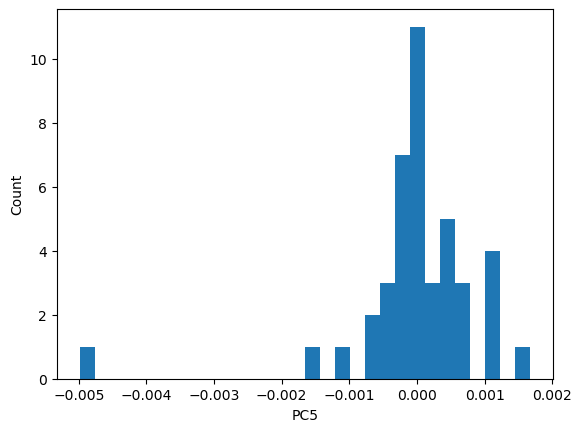

In [95]:
plt.hist(best_df["PC5"], bins=30)
plt.xlabel("PC5")
plt.ylabel("Count")
plt.show()

In [96]:
best_df.loc[best_df["PC5"].abs().idxmax()]

simulation                                            simulation000611
generation                                                         228
solution_index                                                      68
rank                                                                 0
source                                                      population
timestamp                                   2026-05-23T04:32:08.516209
mass                                                              80.0
a_val                                                              2.4
system_size                                                          5
alpha0                                                        6.054272
alpha1                                                       -0.569036
beta1                                                        -0.005803
alpha2                                                       -0.750973
beta2                                                        -0.004931
fitnes

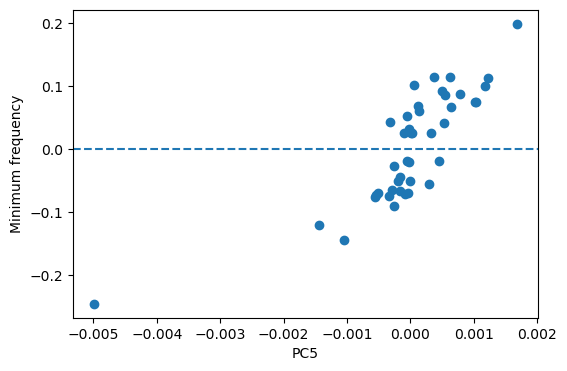

In [97]:
plt.figure(figsize=(6,4))

sc = plt.scatter(
    best_df["PC5"],
    best_df["min_frequency"],
)

plt.xlabel("PC5")
plt.ylabel("Minimum frequency")

plt.axhline(0, linestyle="--")

plt.show()

In [98]:
from scipy.stats import linregress

res = linregress(
    best_df["PC5"],
    best_df["min_frequency"],
)

print(res)

LinregressResult(slope=np.float64(71.05695026616162), intercept=np.float64(0.004536048660242119), rvalue=np.float64(0.8058739362051474), pvalue=np.float64(1.2076282146285385e-10), stderr=np.float64(8.254582216943817), intercept_stderr=np.float64(0.00806586552966334))


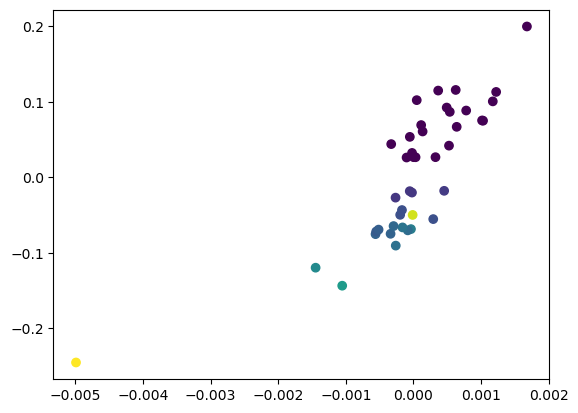

In [99]:
plt.scatter(
    best_df["PC5"],
    best_df["min_frequency"],
    c=best_df["num_imaginary"],
)

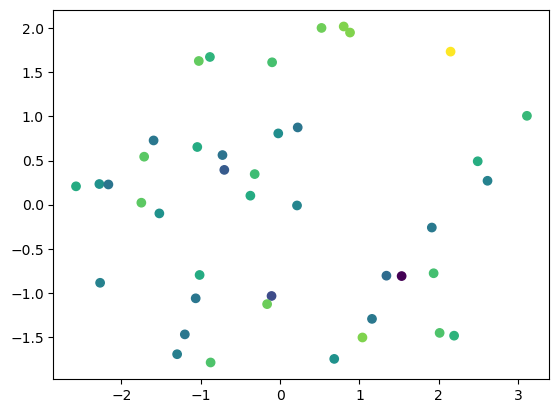

In [100]:
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=best_df["min_frequency"],
)

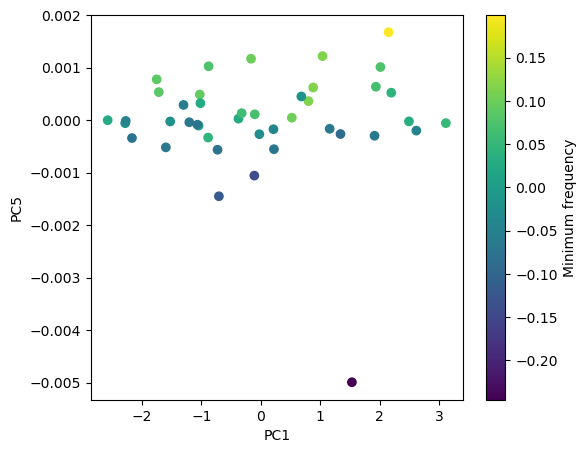

In [101]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,0],
    best_df["PC5"],
    c=best_df["min_frequency"],
)

plt.xlabel("PC1")
plt.ylabel("PC5")

plt.colorbar(sc, label="Minimum frequency")

plt.show()

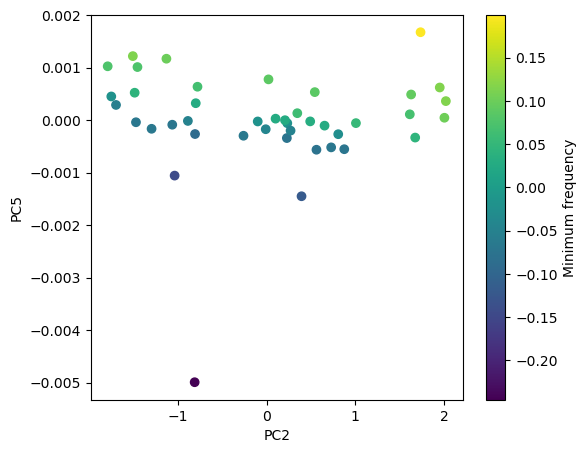

In [102]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,1],
    best_df["PC5"],
    c=best_df["min_frequency"],
)

plt.xlabel("PC2")
plt.ylabel("PC5")

plt.colorbar(sc, label="Minimum frequency")

plt.show()

In [103]:
best_df["frequency_vector"] = best_df["frequencies"].apply(
    lambda x: x.reshape(-1)
)

In [104]:
X_freq = np.stack(best_df["frequency_vector"].values)

In [105]:
X_freq.shape

(42, 2412)

In [106]:
import umap

reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
)

X_umap = reducer.fit_transform(X_freq)

/Users/jamunoz/miniconda3/envs/moga/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


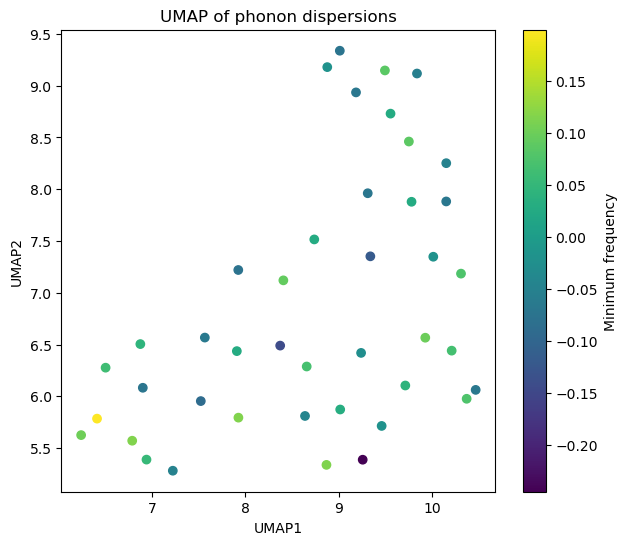

In [107]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=best_df["min_frequency"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="Minimum frequency")

plt.title("UMAP of phonon dispersions")

plt.show()

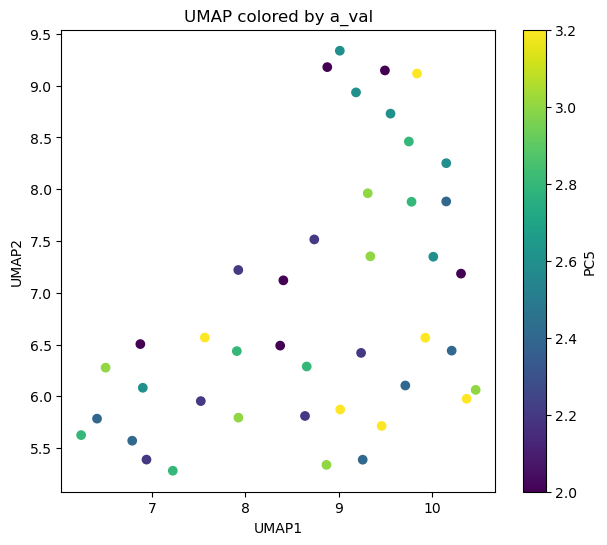

In [108]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=best_df["a_val"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="PC5")

plt.title("UMAP colored by a_val")

plt.show()

In [109]:
fc_cols = [
    "alpha0",
    "alpha1",
    "beta1",
    "alpha2",
    "beta2",
]

X_fc = best_df[fc_cols].values

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_fc_scaled = scaler.fit_transform(X_fc)

In [111]:
import umap

reducer_fc = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
)

X_fc_umap = reducer_fc.fit_transform(X_fc_scaled)

/Users/jamunoz/miniconda3/envs/moga/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


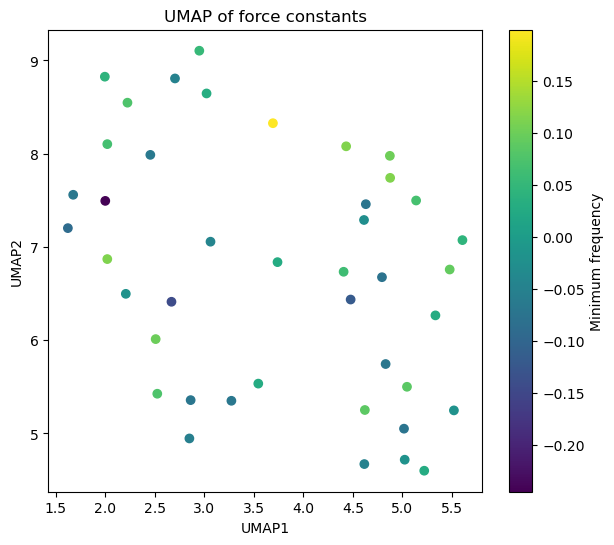

In [112]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_fc_umap[:,0],
    X_fc_umap[:,1],
    c=best_df["min_frequency"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="Minimum frequency")

plt.title("UMAP of force constants")

plt.show()

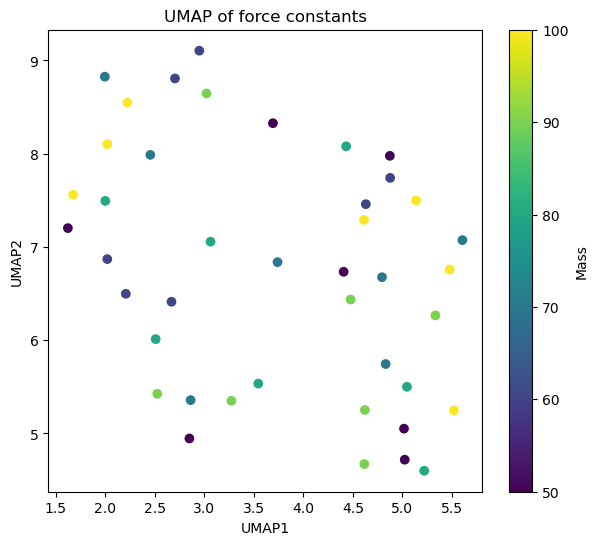

In [113]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_fc_umap[:,0],
    X_fc_umap[:,1],
    c=best_df["mass"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="Mass")

plt.title("UMAP of force constants")

plt.show()

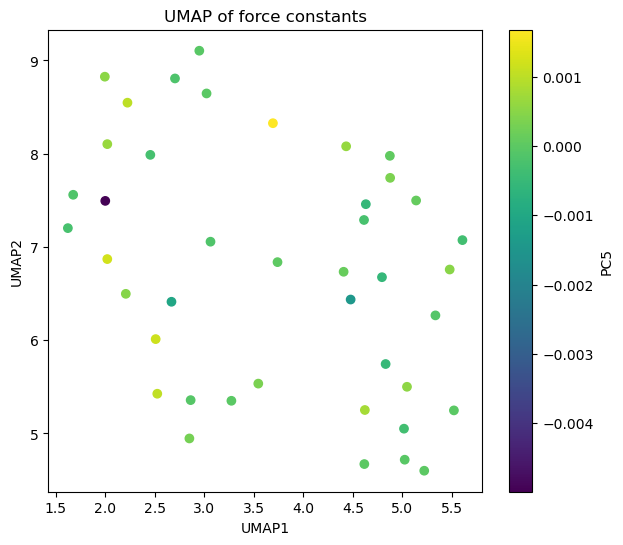

In [114]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_fc_umap[:,0],
    X_fc_umap[:,1],
    c=best_df["PC5"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="PC5")

plt.title("UMAP of force constants")

plt.show()

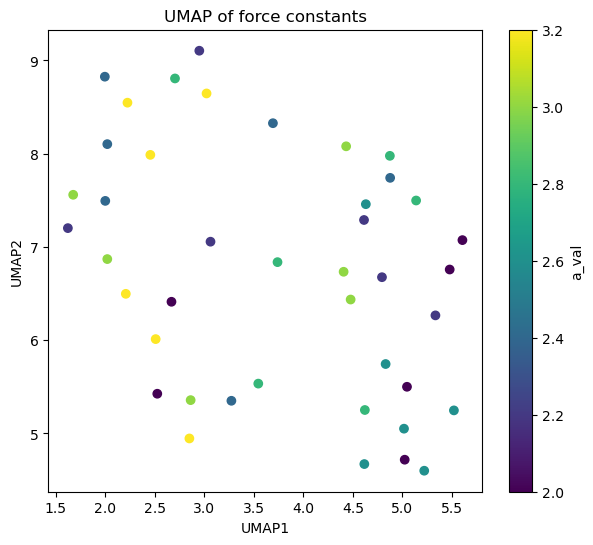

In [115]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_fc_umap[:,0],
    X_fc_umap[:,1],
    c=best_df["a_val"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="a_val")

plt.title("UMAP of force constants")

plt.show()

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr, spearmanr

In [117]:
fc_cols = ["alpha0", "alpha1", "beta1", "alpha2", "beta2"]

X_fc = best_df[fc_cols].to_numpy(dtype=np.float32)

X_ph = np.stack(
    best_df["frequencies"].apply(lambda x: x.reshape(-1)).values
).astype(np.float32)

In [118]:
X_fc_scaled = StandardScaler().fit_transform(X_fc)
X_ph_scaled = StandardScaler().fit_transform(X_ph)

In [119]:
D_fc = pairwise_distances(X_fc_scaled, metric="euclidean")
D_ph = pairwise_distances(X_ph_scaled, metric="euclidean")

In [120]:
iu = np.triu_indices_from(D_fc, k=1)

d_fc = D_fc[iu]
d_ph = D_ph[iu]

r_pearson = pearsonr(d_fc, d_ph)
r_spearman = spearmanr(d_fc, d_ph)

print("Pearson r:", r_pearson.statistic, "p =", r_pearson.pvalue)
print("Spearman rho:", r_spearman.statistic, "p =", r_spearman.pvalue)

Pearson r: 0.46931618 p = 2.262403817875143e-48
Spearman rho: 0.48557621389550726 p = 3.8743841484839375e-52


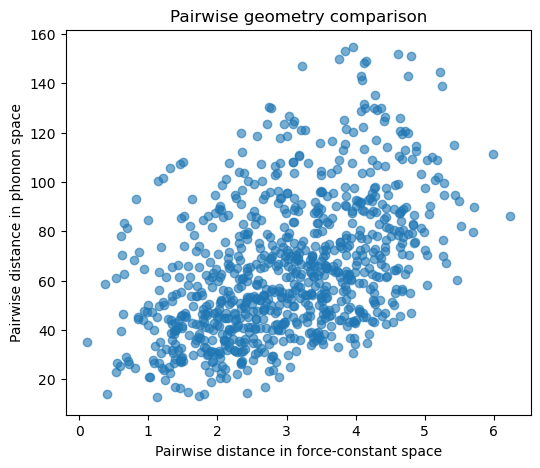

In [121]:
plt.figure(figsize=(6,5))

plt.scatter(d_fc, d_ph, alpha=0.6)

plt.xlabel("Pairwise distance in force-constant space")
plt.ylabel("Pairwise distance in phonon space")
plt.title("Pairwise geometry comparison")

plt.show()

In [122]:
def knn_indices(D, k):
    return np.argsort(D, axis=1)[:, 1:k+1]


def neighborhood_overlap(D1, D2, k):
    nn1 = knn_indices(D1, k)
    nn2 = knn_indices(D2, k)

    overlaps = []

    for a, b in zip(nn1, nn2):
        overlaps.append(
            len(set(a).intersection(set(b))) / k
        )

    return np.array(overlaps)

In [123]:
ks = [1, 2, 3, 5, 8, 10, 15, 20]

overlaps = []

for k in ks:
    ov = neighborhood_overlap(D_fc, D_ph, k)
    overlaps.append(ov.mean())

overlaps = np.array(overlaps)

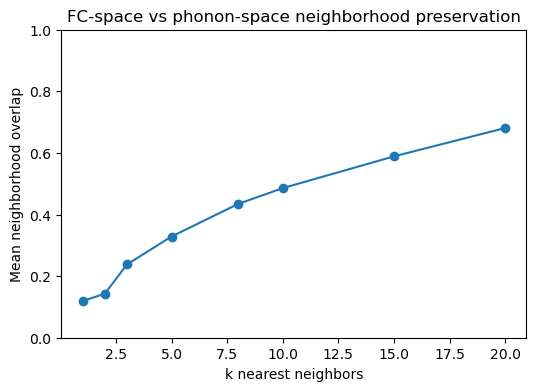

In [124]:
plt.figure(figsize=(6,4))

plt.plot(ks, overlaps, marker="o")

plt.xlabel("k nearest neighbors")
plt.ylabel("Mean neighborhood overlap")
plt.title("FC-space vs phonon-space neighborhood preservation")

plt.ylim(0, 1)

plt.show()

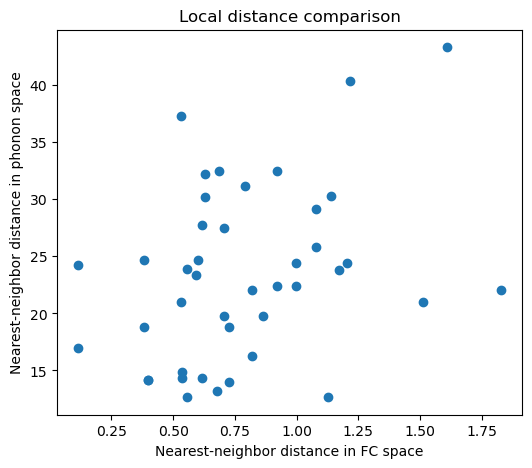

In [125]:
nearest_fc = np.min(D_fc + np.eye(len(D_fc))*1e9, axis=1)
nearest_ph = np.min(D_ph + np.eye(len(D_ph))*1e9, axis=1)

plt.figure(figsize=(6,5))

plt.scatter(nearest_fc, nearest_ph)

plt.xlabel("Nearest-neighbor distance in FC space")
plt.ylabel("Nearest-neighbor distance in phonon space")
plt.title("Local distance comparison")

plt.show()

In [126]:
pairs = pd.DataFrame({
    "i": iu[0],
    "j": iu[1],
    "d_fc": d_fc,
    "d_ph": d_ph,
})

pairs["folding_score"] = pairs["d_fc"] / (pairs["d_ph"] + 1e-8)

folded_pairs = pairs.sort_values("folding_score", ascending=False)

folded_pairs.head(10)

,i,j,d_fc,d_ph,folding_score
152,3,36,2.426519,14.350834,0.169086
68,1,29,2.689050,16.941921,0.158722
257,6,33,2.891551,21.038536,0.137441
386,10,32,1.741602,13.155484,0.132386
215,5,26,1.807032,13.988411,0.129181
566,17,23,3.956672,30.729189,0.128759
44,1,5,3.048316,25.066971,0.121607
401,11,17,4.157737,34.468369,0.120625
221,5,32,2.811566,23.622135,0.119023
645,20,36,2.744087,23.329378,0.117624


In [127]:
i, j = folded_pairs.iloc[0][["i", "j"]].astype(int)

best_df.iloc[[i, j]][
    [
        "simulation",
        "generation",
        "mass",
        "a_val",
        "alpha0",
        "alpha1",
        "beta1",
        "alpha2",
        "beta2",
        "fitness_norm",
        "min_frequency",
        "num_imaginary",
    ]
]

,simulation,generation,mass,a_val,alpha0,alpha1,beta1,alpha2,beta2,fitness_norm,min_frequency,num_imaginary
3,simulation000609,234,80.0,2.0,8.774649,-0.211477,-0.049239,0.001217,-1.770699,1.727458,0.086514,0
36,simulation000594,357,50.0,3.2,5.490830,-0.088012,0.131167,-0.000386,-1.196650,1.716595,-0.055493,14


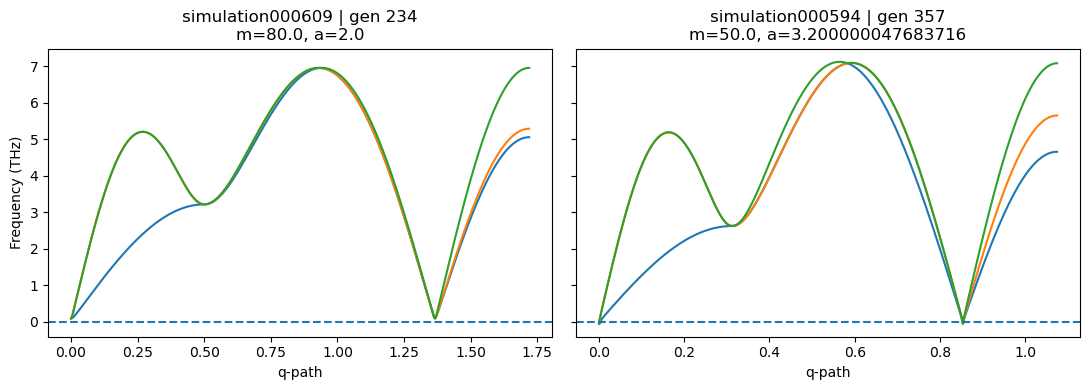

In [128]:
def plot_two_dispersions(row1, row2):
    fig, axes = plt.subplots(1, 2, figsize=(11,4), sharey=True)

    for ax, row in zip(axes, [row1, row2]):
        distances = row["distances"]
        freqs = row["frequencies"]

        for b in range(freqs.shape[1]):
            ax.plot(distances, freqs[:, b])

        ax.axhline(0, linestyle="--")
        ax.set_title(
            f"{row['simulation']} | gen {row['generation']}\n"
            f"m={row['mass']}, a={row['a_val']}"
        )
        ax.set_xlabel("q-path")

    axes[0].set_ylabel("Frequency (THz)")

    plt.tight_layout()
    plt.show()


plot_two_dispersions(best_df.iloc[i], best_df.iloc[j])

,alpha0,alpha1,beta1,alpha2,beta2
count,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000
mean,7.254728,-0.414582,0.009385,-0.335472,-0.817057
std,1.593014,0.239001,0.475392,0.575500,0.669796
min,3.071748,-1.157311,-1.348521,-1.998058,-1.982378
25%,5.811642,-0.587865,-0.311258,-0.644083,-1.356110
50%,7.646986,-0.418439,-0.005803,-0.001817,-0.827943
75%,8.560993,-0.211469,0.339197,0.000248,-0.001577
max,9.994729,0.184210,1.311292,1.078593,0.374455


/var/folders/q4/9jxwyrx94pq6gsv5757mtyf80000gr/T/ipykernel_88562/1057657544.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


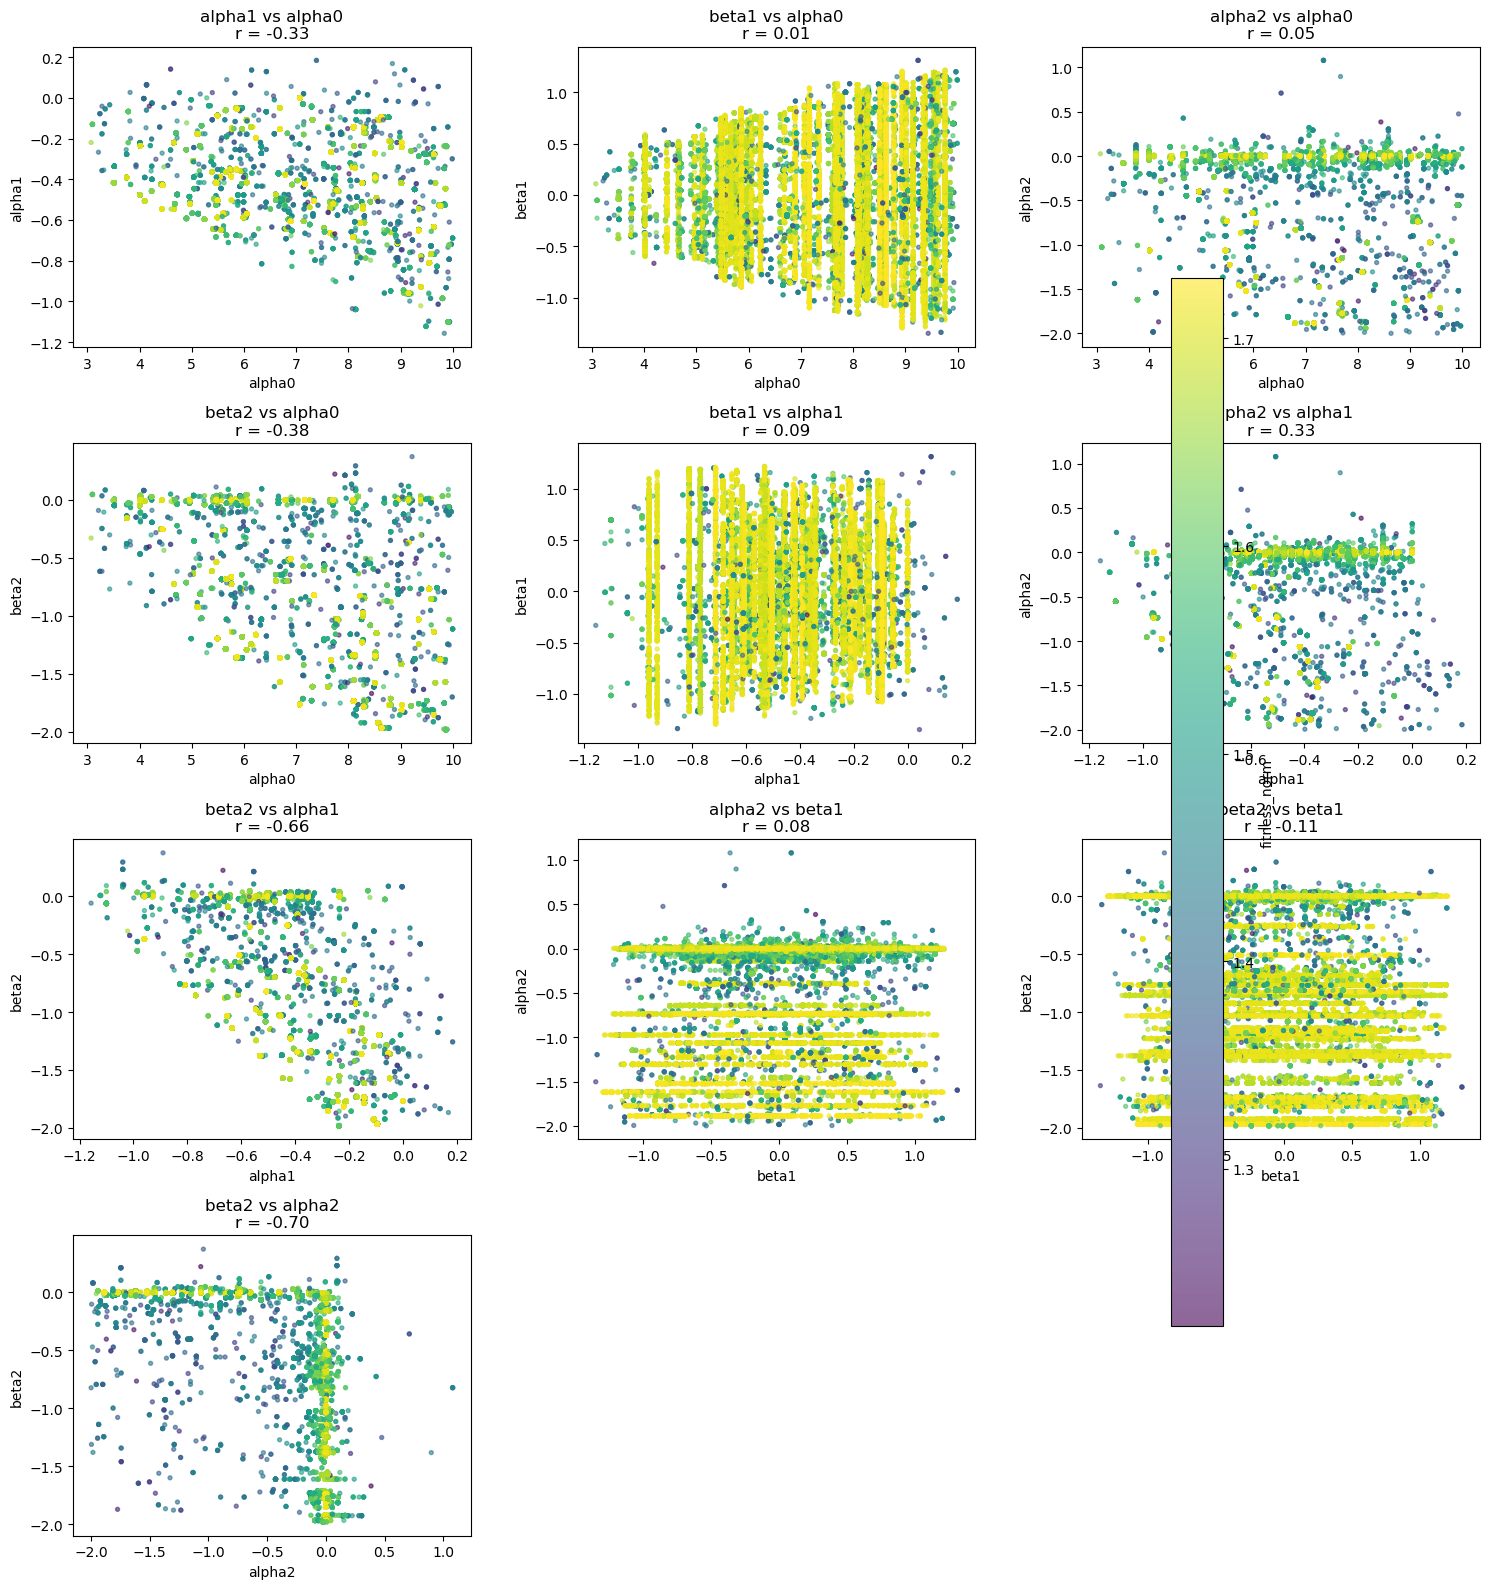

In [129]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]

display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

color_col = "fitness_norm" if "fitness_norm" in df.columns else None

pairs = list(itertools.combinations(fc_cols, 2))

ncols = 3
nrows = int(np.ceil(len(pairs) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5*ncols, 4*nrows),
)

axes = np.ravel(axes)

for ax, (xcol, ycol) in zip(axes, pairs):

    if color_col:
        sc = ax.scatter(
            df[xcol],
            df[ycol],
            c=df[color_col],
            s=8,
            alpha=0.6,
        )
    else:
        ax.scatter(
            df[xcol],
            df[ycol],
            s=8,
            alpha=0.6,
        )

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    r = df[[xcol, ycol]].corr().iloc[0, 1]
    ax.set_title(f"{ycol} vs {xcol}\nr = {r:.2f}")

for ax in axes[len(pairs):]:
    ax.axis("off")

if color_col:
    cbar = fig.colorbar(sc, ax=axes.tolist(), shrink=0.85)
    cbar.set_label(color_col)

plt.tight_layout()
plt.show()